Running: fixed


100%|██████████| 72/72 [00:03<00:00, 18.42it/s]


Using reference frequency: 70.00 MHz


100%|██████████| 72/72 [00:04<00:00, 15.73it/s]


Running: stepped


...

100%|██████████| 72/72 [00:03<00:00, 21.85it/s]


Running: continuous


100%|██████████| 72/72 [00:03<00:00, 20.92it/s]


Using reference frequency: 70.00 MHz


100%|██████████| 72/72 [00:03<00:00, 23.60it/s]


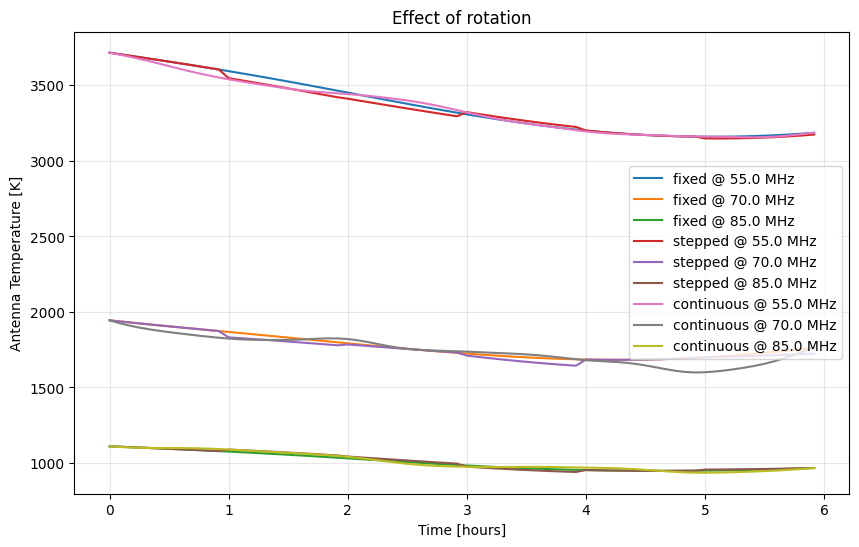

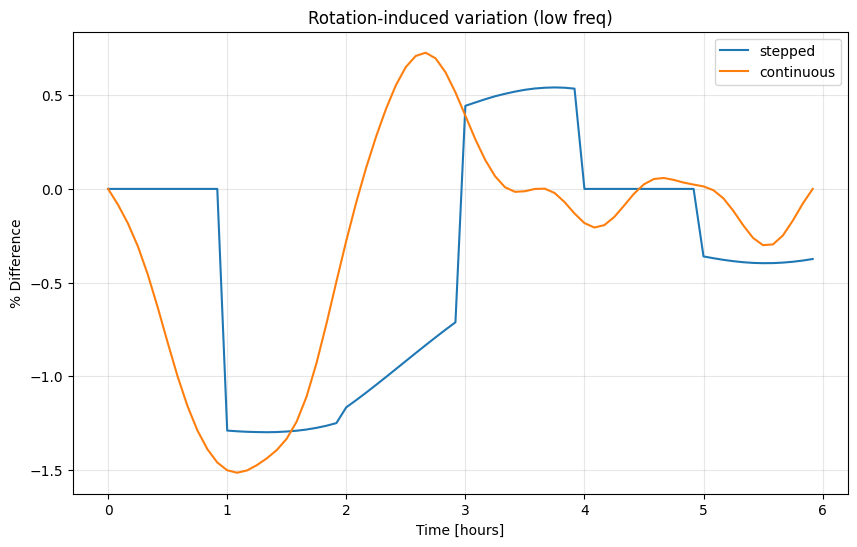

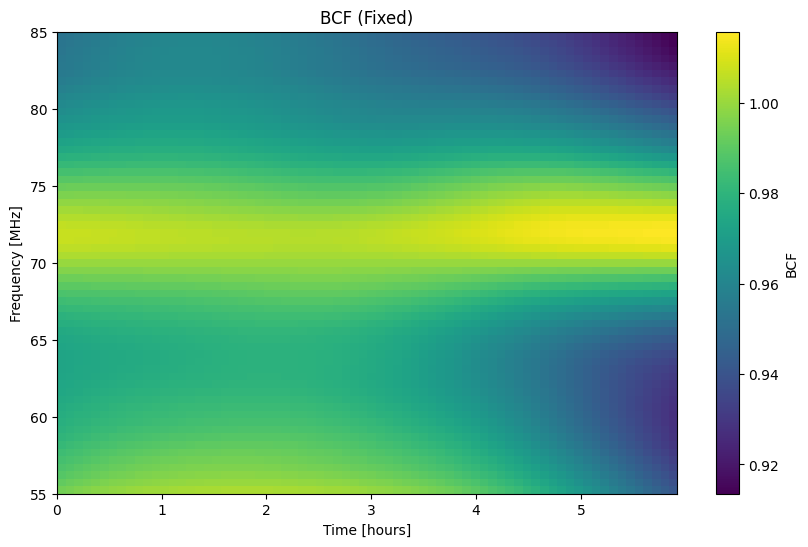

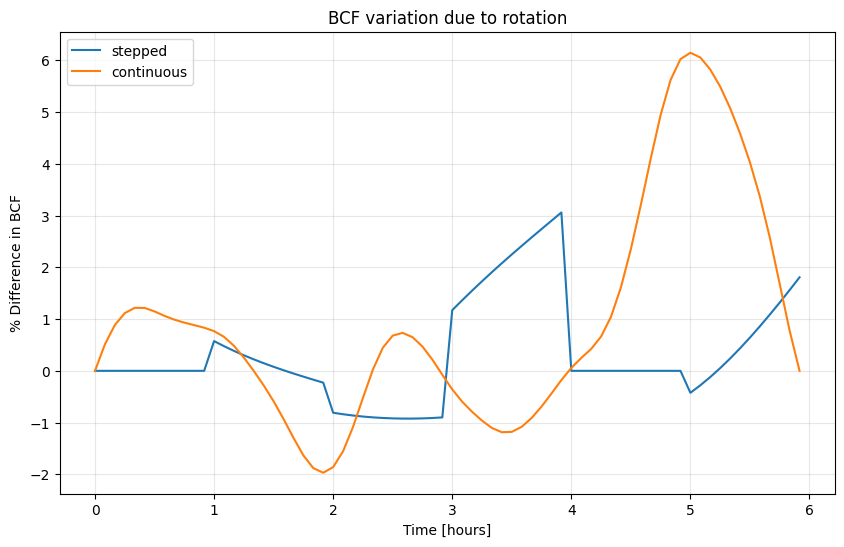

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from astropy.io import fits
import glob, re

from limTOD import generate_TOD_sky, generate_LSTs_deg
from limTOD import GDSM_sky_model

# ============================================================
# CONFIG
# ============================================================

BEAM_GLOB = "../data/HornDry/HornDry*.fits"

ANT_LAT = 53.2421
ANT_LON = -2.3067
ANT_H   = 100

START_TIME = "2026-04-01 20:41:56.397"

# 6-hour observation
DT = 300   # 5 min sampling
N_TIME = int((6 * 3600) / DT)

time_list = np.arange(N_TIME) * DT
time_hours = time_list / 3600

BEAM_NSIDE = 512
SKY_NSIDE = 64
NSIDE_HIRES = 128

# ============================================================
# LOAD BEAMS
# ============================================================

beam_files = sorted(glob.glob(BEAM_GLOB))

beam_dict = {}

for f in beam_files:
    freq = float(re.search(r"(\d+\.\d+)", f).group(1))

    with fits.open(f) as hdul:
        beam = np.array(hdul[1].data.field(0)).reshape(-1)

    beam = np.nan_to_num(beam)
    beam[beam < 0] = 0
    beam /= np.sum(beam)

    beam_dict[freq] = beam

freq_list = np.array(sorted(beam_dict.keys()))

def beam_func(freq, nside):
    f_near = freq_list[np.argmin(np.abs(freq_list - freq))]
    beam = beam_dict[f_near]

    if hp.npix2nside(len(beam)) != nside:
        beam = hp.ud_grade(beam, nside_out=nside, power=-2)

    return beam / np.sum(beam)

# ============================================================
# SKY + LST
# ============================================================

LST_deg = generate_LSTs_deg(
    ANT_LAT, ANT_LON, ANT_H,
    time_list,
    start_time_utc=START_TIME
)

az_list = np.zeros(N_TIME)
el_list = np.full(N_TIME, 90.0)

# ============================================================
# ROTATION MODELS
# ============================================================

# fixed
sr_fixed = np.zeros(N_TIME)

# stepped (change every hour)
sr_step = np.zeros(N_TIME)
step_deg = [0, 45, 90, 135]
for i in range(N_TIME):
    sr_step[i] = step_deg[(i // (3600 // DT)) % len(step_deg)]

# continuous
sr_cont = (time_list / time_list[-1]) * 360

rotation_cases = {
    "fixed": sr_fixed,
    "stepped": sr_step,
    "continuous": sr_cont
}

# ============================================================
# COMPUTE ANTENNA TEMPERATURE
# ============================================================

def compute_T(sr_list):

    T = np.zeros((len(freq_list), N_TIME))

    for i, nu in enumerate(freq_list):

        beam = beam_func(nu, BEAM_NSIDE)
        sky = GDSM_sky_model(freq=nu, nside=SKY_NSIDE)

        T[i] = generate_TOD_sky(
            beam, sky,
            LST_deg, ANT_LAT,
            az_list, el_list, sr_list,
            nside_hires=NSIDE_HIRES,
            normalize_beam=True
        )

    return T

# ============================================================
# COMPUTE BCF (FROM PAPER EQ. 4)
# ============================================================

def compute_BCF(sr_list, nu_ref=70.0):

    # reference frequency
    nu_ref_idx = np.argmin(np.abs(freq_list - nu_ref))
    nu_ref_actual = freq_list[nu_ref_idx]
    print(f"Using reference frequency: {nu_ref_actual:.2f} MHz")

    # sky at reference frequency
    sky_ref = GDSM_sky_model(freq=nu_ref_actual, nside=SKY_NSIDE)

    # reference beam
    beam_ref = beam_func(nu_ref_actual, BEAM_NSIDE)

    # denominator (time dependent)
    T_ref = generate_TOD_sky(
        beam_ref, sky_ref,
        LST_deg, ANT_LAT,
        az_list, el_list, sr_list,
        nside_hires=NSIDE_HIRES,
        normalize_beam=True
    )

    BCF = np.zeros((len(freq_list), N_TIME))

    for i, nu in enumerate(freq_list):

        beam = beam_func(nu, BEAM_NSIDE)

        T_num = generate_TOD_sky(
            beam, sky_ref,
            LST_deg, ANT_LAT,
            az_list, el_list, sr_list,
            nside_hires=NSIDE_HIRES,
            normalize_beam=True
        )

        BCF[i] = T_num / T_ref

    return BCF

# ============================================================
# RUN SIMULATIONS
# ============================================================

results = {}
bcf_results = {}

for name, sr in rotation_cases.items():
    print("Running:", name)

    results[name] = compute_T(sr)
    bcf_results[name] = compute_BCF(sr)

# ============================================================
# PLOT 1 — TIME SERIES
# ============================================================

plt.figure(figsize=(10,6))

freq_indices = [0, len(freq_list)//2, -1]

for name, T in results.items():
    for idx in freq_indices:
        plt.plot(
            time_hours,
            T[idx],
            label=f"{name} @ {freq_list[idx]:.1f} MHz"
        )

plt.xlabel("Time [hours]")
plt.ylabel("Antenna Temperature [K]")
plt.title("Effect of rotation")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# PLOT 2 — ANTENNA TEMP DIFFERENCE
# ============================================================

plt.figure(figsize=(10,6))

T_ref = results["fixed"]

for name in ["stepped", "continuous"]:
    diff = (results[name] - T_ref) / T_ref * 100
    plt.plot(time_hours, diff[0], label=name)

plt.xlabel("Time [hours]")
plt.ylabel("% Difference")
plt.title("Rotation-induced variation (low freq)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# PLOT 3 — BCF WATERFALL
# ============================================================

plt.figure(figsize=(10,6))

plt.imshow(
    bcf_results["fixed"],
    aspect="auto",
    origin="lower",
    extent=[time_hours[0], time_hours[-1],
            freq_list[0], freq_list[-1]]
)

plt.colorbar(label="BCF")
plt.xlabel("Time [hours]")
plt.ylabel("Frequency [MHz]")
plt.title("BCF (Fixed)")
plt.show()

# ============================================================
# PLOT 4 — BCF DIFFERENCE
# ============================================================

plt.figure(figsize=(10,6))

bcf_ref = bcf_results["fixed"]

for name in ["stepped", "continuous"]:
    diff = (bcf_results[name] - bcf_ref) / bcf_ref * 100
    plt.plot(time_hours, diff[0], label=name)

plt.xlabel("Time [hours]")
plt.ylabel("% Difference in BCF")
plt.title("BCF variation due to rotation")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### with BCF

Using horn beam at target frequency 55.00 MHz
Using horn beam at reference frequency 70.00 MHz


100%|██████████| 360/360 [00:15<00:00, 23.47it/s]


Raw TOD shape: (360,)


100%|██████████| 360/360 [00:14<00:00, 24.12it/s]


BCF shape: (360,)
BCF min = 0.950264, max = 1.032283
BCF-corrected TOD shape: (360,)

Step 1: Generating the stacked abs(beam) map ... 



100%|██████████| 360/360 [00:14<00:00, 24.45it/s]



Step 2: Selecting pixels above threshold sensitivity ... 

Number of data points: 360
Number of selected pixels: 962


100%|██████████| 360/360 [00:15<00:00, 23.84it/s]


Recovered sky parameter shape: (962,)
Recovered uncertainty shape: (962,)
Number of selected pixels: 962


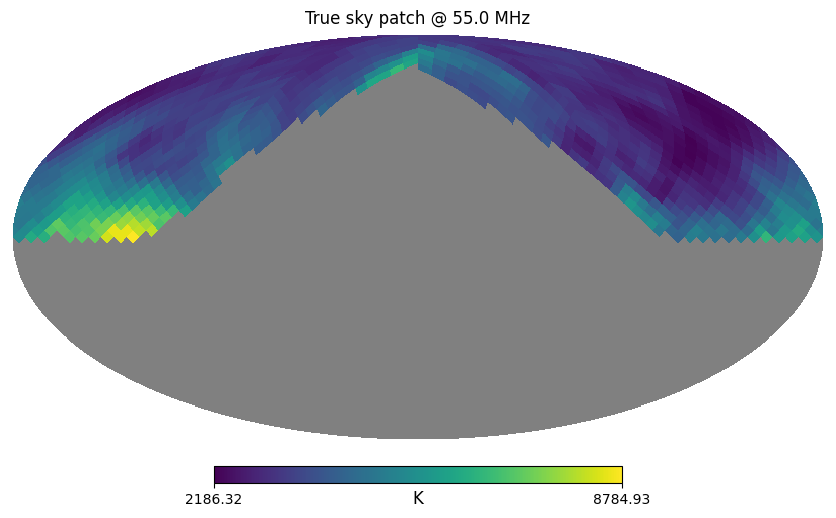

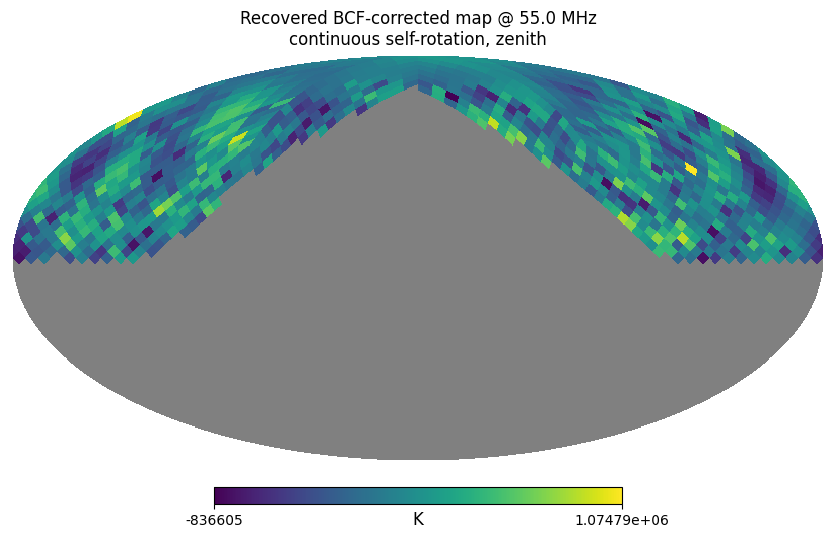

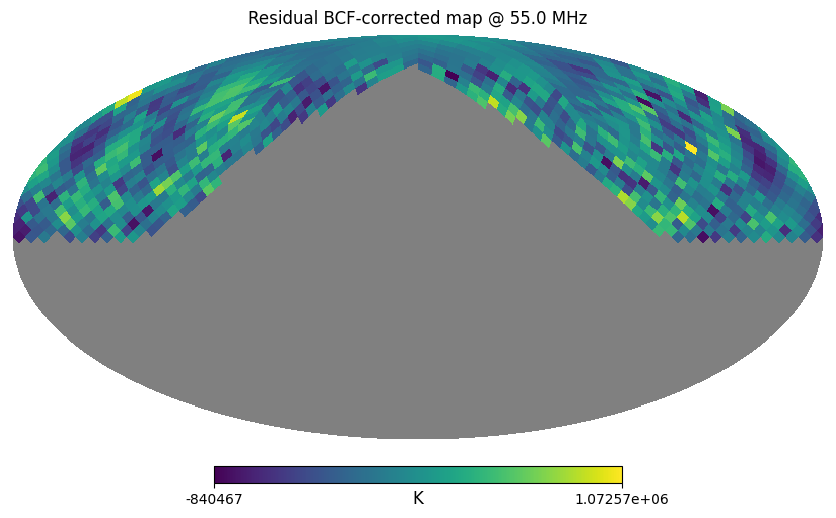

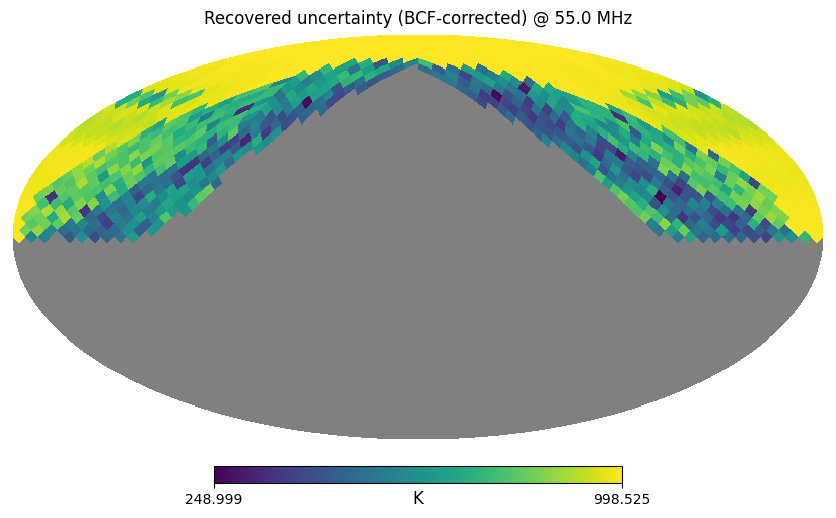

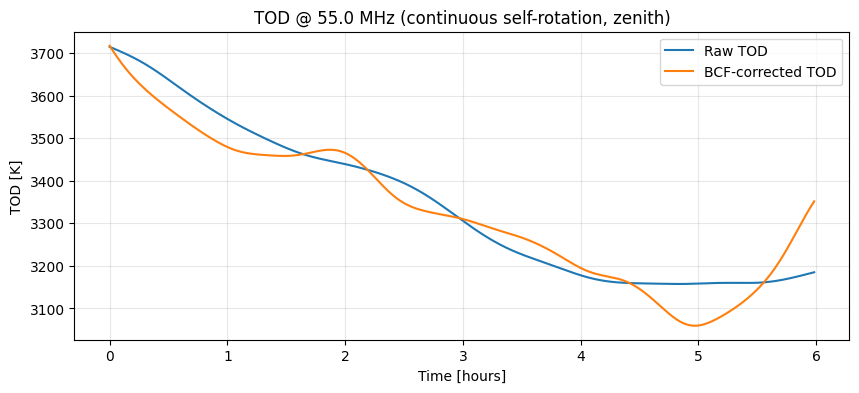

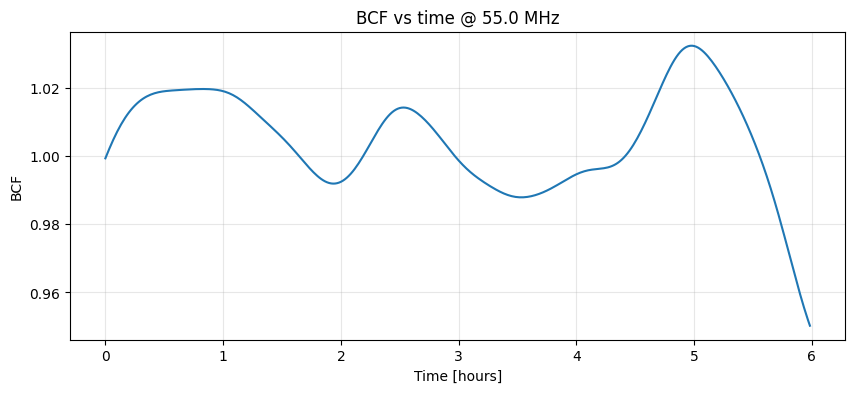

Patch RMSE (BCF-corrected): 307024.563 K
Patch bias (BCF-corrected): -25521.494 K


In [3]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from astropy.io import fits
import glob
import re

from limTOD import generate_LSTs_deg, generate_TOD_sky, GDSM_sky_model, HPW_mapmaking

# ============================================================
# CONFIG
# ============================================================

BEAM_GLOB = "../data/HornWet/HornWet*.fits"

ANT_LAT = 53.2421
ANT_LON = -2.3067
ANT_H   = 100.0

START_TIME = "2026-04-01 20:41:56.397"

DT = 60.0                       # 5 min cadence
N_HOURS = 6
N_TIME = int((N_HOURS * 3600) / DT)

time_list = np.arange(N_TIME) * DT
time_hours = time_list / 3600.0

BEAM_NSIDE = 128
SKY_NSIDE = 64
MAP_NSIDE = 16                  # target map nside for reconstruction

TARGET_FREQ = 50.0              # target horn-beam channel
REF_FREQ = 70.0                 # BCF reference frequency

# continuous self rotation: 0 -> 360 over whole observation
selfrot_deg_list = (time_list / time_list[-1]) * 360.0

# zenith pointing
azimuth_deg_list = np.zeros(N_TIME)
elevation_deg_list = np.full(N_TIME, 90.0)

# ============================================================
# LOAD HORN BEAMS
# ============================================================

beam_files = sorted(glob.glob(BEAM_GLOB))
if len(beam_files) == 0:
    raise FileNotFoundError(f"No beam FITS found matching {BEAM_GLOB}")

beam_dict = {}

for f in beam_files:
    m = re.search(r"(\d+\.\d+)", f)
    if m is None:
        continue

    freq = float(m.group(1))

    with fits.open(f) as hdul:
        beam = np.array(hdul[1].data.field(0)).reshape(-1)

    beam = np.nan_to_num(beam)
    beam[beam < 0] = 0.0
    beam /= np.sum(beam)

    beam_dict[freq] = beam

freq_list = np.array(sorted(beam_dict.keys()))
if len(freq_list) == 0:
    raise RuntimeError("No usable horn beams were loaded.")

def get_horn_beam_for_freq(freq, nside=BEAM_NSIDE):
    f_near = freq_list[np.argmin(np.abs(freq_list - freq))]
    beam = beam_dict[f_near].copy()

    native_nside = hp.npix2nside(len(beam))
    if native_nside != nside:
        beam = hp.ud_grade(beam, nside_out=nside, power=-2)

    beam = np.nan_to_num(beam)
    beam[beam < 0] = 0.0

    s = np.sum(beam)
    if s <= 0:
        raise ValueError(f"Beam at {f_near} MHz has zero total weight.")
    beam /= s

    return f_near, beam

beam_freq_used, beam_map = get_horn_beam_for_freq(TARGET_FREQ, nside=BEAM_NSIDE)
ref_freq_used, beam_ref_map = get_horn_beam_for_freq(REF_FREQ, nside=BEAM_NSIDE)

print(f"Using horn beam at target frequency {beam_freq_used:.2f} MHz")
print(f"Using horn beam at reference frequency {ref_freq_used:.2f} MHz")

# ============================================================
# GENERATE SKY + LST
# ============================================================

LST_deg_list = generate_LSTs_deg(
    ANT_LAT,
    ANT_LON,
    ANT_H,
    time_list,
    start_time_utc=START_TIME,
)

sky_map = GDSM_sky_model(freq=beam_freq_used, nside=SKY_NSIDE)
sky_ref_map = GDSM_sky_model(freq=ref_freq_used, nside=SKY_NSIDE)

# ============================================================
# GENERATE RAW TOD FOR TARGET FREQUENCY CHANNEL
# ============================================================

tod = generate_TOD_sky(
    beam_map,
    sky_map,
    LST_deg_list,
    ANT_LAT,
    azimuth_deg_list,
    elevation_deg_list,
    selfrot_deg_list,
    nside_hires=BEAM_NSIDE,
    normalize_beam=True,
)

print("Raw TOD shape:", tod.shape)

# ============================================================
# COMPUTE BCF
# ============================================================
# Using the paper-style normalized-beam form:
# BCF(t) = [integral T_sky(nu_ref) * B(nu)] / [integral T_sky(nu_ref) * B(nu_ref)]
#
# Since your beams are explicitly normalized on load, this is the
# appropriate form for this script.

T_num = generate_TOD_sky(
    beam_map,
    sky_ref_map,
    LST_deg_list,
    ANT_LAT,
    azimuth_deg_list,
    elevation_deg_list,
    selfrot_deg_list,
    nside_hires=BEAM_NSIDE,
    normalize_beam=True,
)

T_ref = generate_TOD_sky(
    beam_ref_map,
    sky_ref_map,
    LST_deg_list,
    ANT_LAT,
    azimuth_deg_list,
    elevation_deg_list,
    selfrot_deg_list,
    nside_hires=BEAM_NSIDE,
    normalize_beam=True,
)

eps = 1e-12
BCF = T_num / np.maximum(T_ref, eps)

print("BCF shape:", BCF.shape)
print(f"BCF min = {BCF.min():.6f}, max = {BCF.max():.6f}")

# ============================================================
# APPLY BCF TO TOD ITSELF
# ============================================================

tod_bcf_corr = tod / np.maximum(BCF, eps)

print("BCF-corrected TOD shape:", tod_bcf_corr.shape)

# ============================================================
# MAP MAKER SETUP
# ============================================================

mapper = HPW_mapmaking(
    beam_map=beam_map,
    LST_deg_list_group=LST_deg_list,
    lat_deg=ANT_LAT,
    azimuth_deg_list_group=azimuth_deg_list,
    elevation_deg_list_group=elevation_deg_list,
    selfrot_deg_list_group=selfrot_deg_list,
    threshold=0.05,
    nside_hires=BEAM_NSIDE,
    nside_target=MAP_NSIDE,
    beam_truncate_frac_thres=0.01,
)

# ============================================================
# RUN MAP MAKING ON BCF-CORRECTED TOD
# ============================================================

sky_estimation, sky_uncertainty = mapper(
    TOD_group=tod_bcf_corr,      # <-- corrected TOD goes into solver
    dtime=DT,
    cutoff_freq_group=0.001,
    gain_group=1.0,
    regularization=1e-6,
    filter_order=4,
)

pixel_indices = mapper.pixel_indices

print("Recovered sky parameter shape:", sky_estimation.shape)
print("Recovered uncertainty shape:", sky_uncertainty.shape)
print("Number of selected pixels:", len(pixel_indices))

# ============================================================
# PUT PATCH BACK INTO FULL HEALPIX MAP
# ============================================================

npix_target = hp.nside2npix(MAP_NSIDE)

recovered_map_full = np.full(npix_target, hp.UNSEEN, dtype=float)
uncertainty_map_full = np.full(npix_target, hp.UNSEEN, dtype=float)

recovered_map_full[pixel_indices] = sky_estimation
uncertainty_map_full[pixel_indices] = sky_uncertainty

# truth map at target nside for comparison
truth_map_target = hp.ud_grade(sky_map, nside_out=MAP_NSIDE)

truth_patch_full = np.full(npix_target, hp.UNSEEN, dtype=float)
truth_patch_full[pixel_indices] = truth_map_target[pixel_indices]

residual_map_full = np.full(npix_target, hp.UNSEEN, dtype=float)
residual_map_full[pixel_indices] = sky_estimation - truth_map_target[pixel_indices]

# ============================================================
# PLOTS
# ============================================================

hp.mollview(
    truth_patch_full,
    title=f"True sky patch @ {beam_freq_used:.1f} MHz",
    unit="K"
)

hp.mollview(
    recovered_map_full,
    title=f"Recovered BCF-corrected map @ {beam_freq_used:.1f} MHz\ncontinuous self-rotation, zenith",
    unit="K"
)

hp.mollview(
    residual_map_full,
    title=f"Residual BCF-corrected map @ {beam_freq_used:.1f} MHz",
    unit="K"
)

hp.mollview(
    uncertainty_map_full,
    title=f"Recovered uncertainty (BCF-corrected) @ {beam_freq_used:.1f} MHz",
    unit="K"
)

plt.figure(figsize=(10, 4))
plt.plot(time_hours, tod, label="Raw TOD")
plt.plot(time_hours, tod_bcf_corr, label="BCF-corrected TOD")
plt.xlabel("Time [hours]")
plt.ylabel("TOD [K]")
plt.title(f"TOD @ {beam_freq_used:.1f} MHz (continuous self-rotation, zenith)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_hours, BCF)
plt.xlabel("Time [hours]")
plt.ylabel("BCF")
plt.title(f"BCF vs time @ {beam_freq_used:.1f} MHz")
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# SIMPLE SUMMARY METRICS ON THE SOLVED PATCH
# ============================================================

valid = pixel_indices
rmse = np.sqrt(np.mean((sky_estimation - truth_map_target[valid])**2))
bias = np.mean(sky_estimation - truth_map_target[valid])

print(f"Patch RMSE (BCF-corrected): {rmse:.3f} K")
print(f"Patch bias (BCF-corrected): {bias:.3f} K")

Using horn beam at target frequency 55.00 MHz
Using horn beam at reference frequency 70.00 MHz


100%|██████████| 1440/1440 [01:08<00:00, 21.05it/s]


Raw TOD shape: (1440,)


100%|██████████| 1440/1440 [01:00<00:00, 23.69it/s]


BCF shape: (1440,)
BCF min = 0.953687, max = 1.079469
BCF-corrected TOD shape: (1440,)

Step 1: Generating the stacked abs(beam) map ... 



100%|██████████| 1440/1440 [01:08<00:00, 21.00it/s]



Step 2: Selecting pixels above threshold sensitivity ... 

Number of data points: 1440
Number of selected pixels: 24750


100%|██████████| 1440/1440 [01:06<00:00, 21.74it/s]


Recovered sky parameter shape: (24750,)
Recovered uncertainty shape: (24750,)
Number of selected pixels: 24750


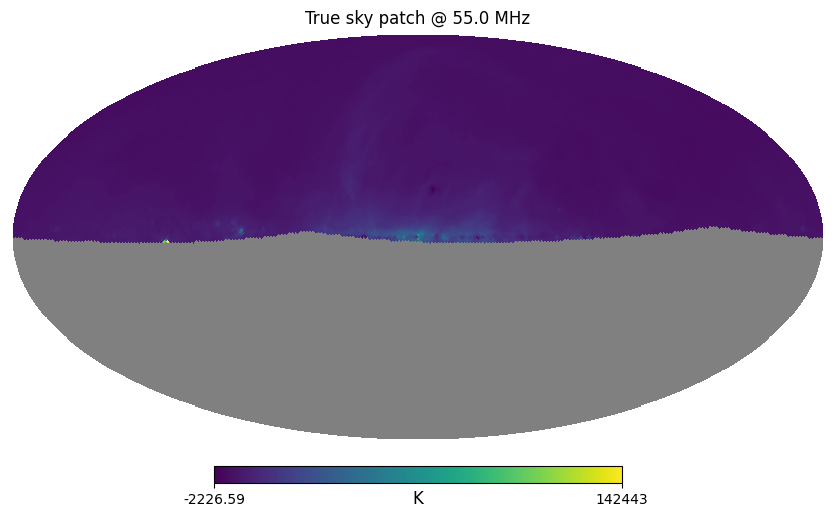

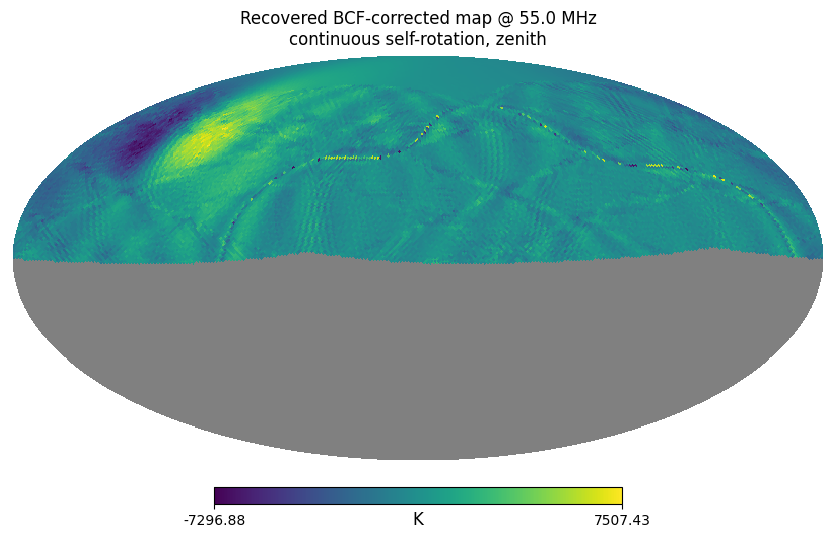

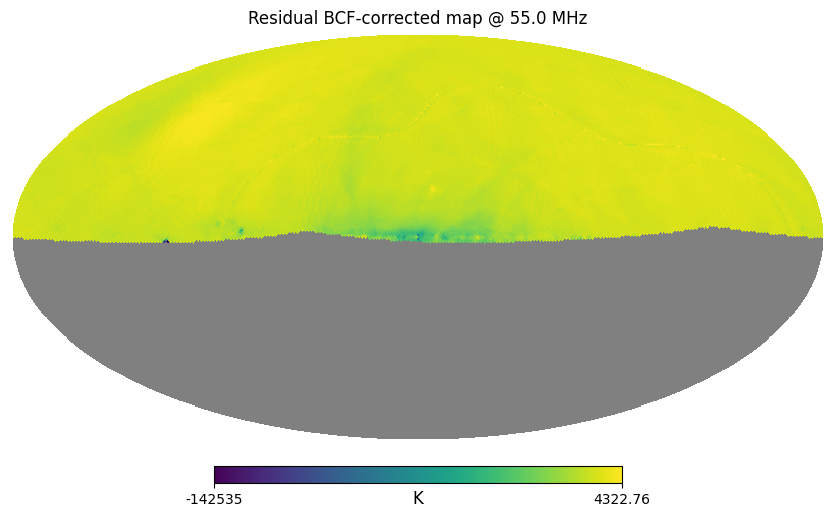

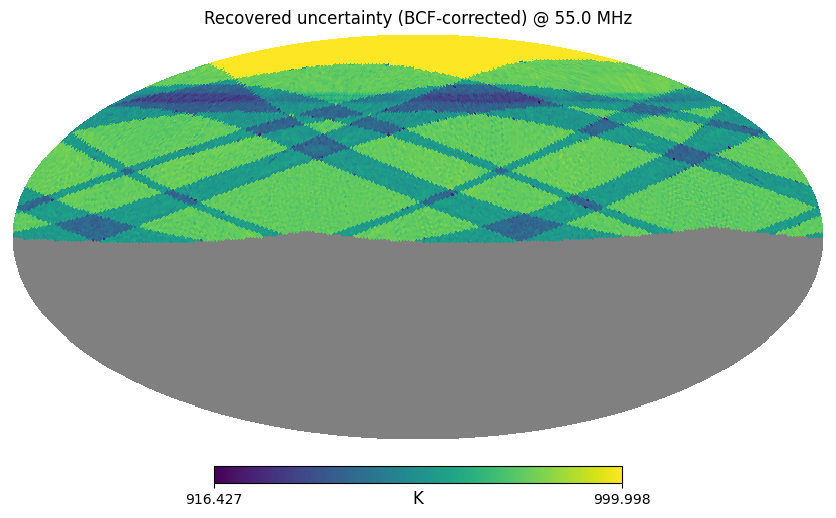

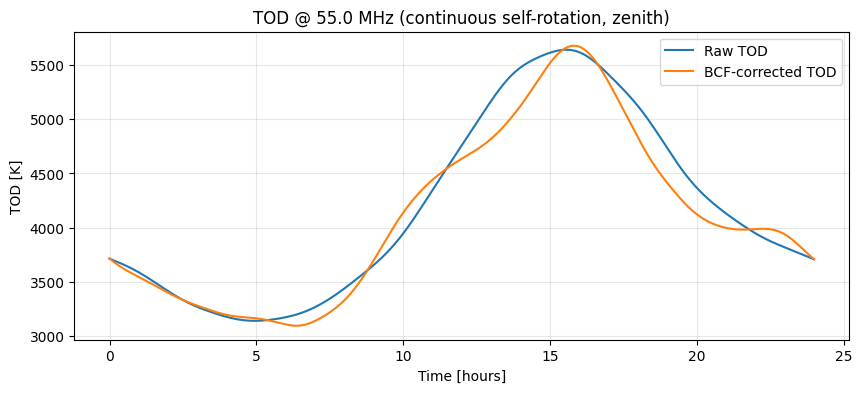

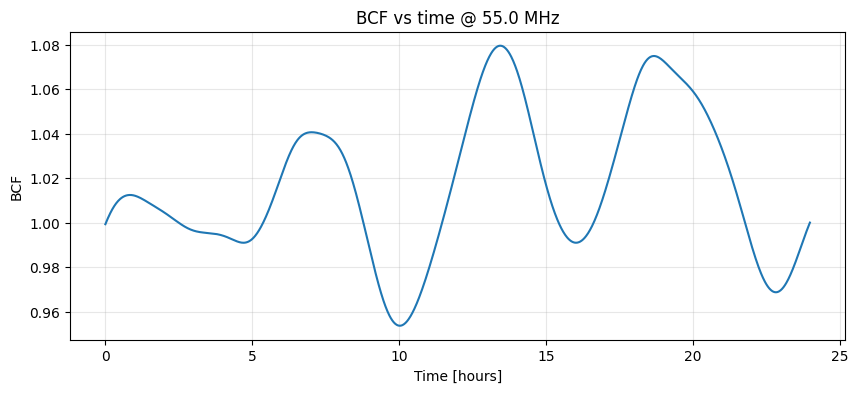

Patch RMSE (BCF-corrected): 7234.522 K
Patch bias (BCF-corrected): -5517.074 K


In [ ]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from astropy.io import fits
import glob
import re

from limTOD import generate_LSTs_deg, generate_TOD_sky, GDSM_sky_model, HPW_mapmaking

# ============================================================
# CONFIG
# ============================================================

BEAM_GLOB = "../data/HornWet/HornWet*.fits"

ANT_LAT = 53.2421
ANT_LON = -2.3067
ANT_H   = 100.0

START_TIME = "2026-04-01 20:41:56.397"

DT = 60.0                       # 1 min cadence
N_HOURS = 24
N_TIME = int((N_HOURS * 3600) / DT)

time_list = np.arange(N_TIME) * DT
time_hours = time_list / 3600.0

BEAM_NSIDE = 128
SKY_NSIDE = 64
MAP_NSIDE = 64                  # target map nside for reconstruction

TARGET_FREQ = 55.0              # target horn-beam channel
REF_FREQ = 70.0                 # BCF reference frequency

# continuous self rotation: 0 -> 360 over whole observation
selfrot_deg_list = (time_list / time_list[-1]) * 360.0

# zenith pointing
azimuth_deg_list = np.zeros(N_TIME)
elevation_deg_list = np.full(N_TIME, 90.0)

# ============================================================
# LOAD HORN BEAMS
# ============================================================

beam_files = sorted(glob.glob(BEAM_GLOB))
if len(beam_files) == 0:
    raise FileNotFoundError(f"No beam FITS found matching {BEAM_GLOB}")

beam_dict = {}

for f in beam_files:
    m = re.search(r"(\d+\.\d+)", f)
    if m is None:
        continue

    freq = float(m.group(1))

    with fits.open(f) as hdul:
        beam = np.array(hdul[1].data.field(0)).reshape(-1)

    beam = np.nan_to_num(beam)
    beam[beam < 0] = 0.0
    beam /= np.sum(beam)

    beam_dict[freq] = beam

freq_list = np.array(sorted(beam_dict.keys()))
if len(freq_list) == 0:
    raise RuntimeError("No usable horn beams were loaded.")

def get_horn_beam_for_freq(freq, nside=BEAM_NSIDE):
    f_near = freq_list[np.argmin(np.abs(freq_list - freq))]
    beam = beam_dict[f_near].copy()

    native_nside = hp.npix2nside(len(beam))
    if native_nside != nside:
        beam = hp.ud_grade(beam, nside_out=nside, power=-2)

    beam = np.nan_to_num(beam)
    beam[beam < 0] = 0.0

    s = np.sum(beam)
    if s <= 0:
        raise ValueError(f"Beam at {f_near} MHz has zero total weight.")
    beam /= s

    return f_near, beam

beam_freq_used, beam_map = get_horn_beam_for_freq(TARGET_FREQ, nside=BEAM_NSIDE)
ref_freq_used, beam_ref_map = get_horn_beam_for_freq(REF_FREQ, nside=BEAM_NSIDE)

print(f"Using horn beam at target frequency {beam_freq_used:.2f} MHz")
print(f"Using horn beam at reference frequency {ref_freq_used:.2f} MHz")

# ============================================================
# GENERATE SKY + LST
# ============================================================

LST_deg_list = generate_LSTs_deg(
    ANT_LAT,
    ANT_LON,
    ANT_H,
    time_list,
    start_time_utc=START_TIME,
)

sky_map = GDSM_sky_model(freq=beam_freq_used, nside=SKY_NSIDE)
sky_ref_map = GDSM_sky_model(freq=ref_freq_used, nside=SKY_NSIDE)

# ============================================================
# GENERATE RAW TOD FOR TARGET FREQUENCY CHANNEL
# ============================================================

tod = generate_TOD_sky(
    beam_map,
    sky_map,
    LST_deg_list,
    ANT_LAT,
    azimuth_deg_list,
    elevation_deg_list,
    selfrot_deg_list,
    nside_hires=BEAM_NSIDE,
    normalize_beam=True,
)

print("Raw TOD shape:", tod.shape)

# ============================================================
# COMPUTE BCF
# ============================================================
# Using the paper-style normalized-beam form:
# BCF(t) = [integral T_sky(nu_ref) * B(nu)] / [integral T_sky(nu_ref) * B(nu_ref)]
#
# Since your beams are explicitly normalized on load, this is the
# appropriate form for this script.

T_num = generate_TOD_sky(
    beam_map,
    sky_ref_map,
    LST_deg_list,
    ANT_LAT,
    azimuth_deg_list,
    elevation_deg_list,
    selfrot_deg_list,
    nside_hires=BEAM_NSIDE,
    normalize_beam=True,
)

T_ref = generate_TOD_sky(
    beam_ref_map,
    sky_ref_map,
    LST_deg_list,
    ANT_LAT,
    azimuth_deg_list,
    elevation_deg_list,
    selfrot_deg_list,
    nside_hires=BEAM_NSIDE,
    normalize_beam=True,
)

eps = 1e-12
BCF = T_num / np.maximum(T_ref, eps)

print("BCF shape:", BCF.shape)
print(f"BCF min = {BCF.min():.6f}, max = {BCF.max():.6f}")

# ============================================================
# APPLY BCF TO TOD ITSELF
# ============================================================

tod_bcf_corr = tod / np.maximum(BCF, eps)

print("BCF-corrected TOD shape:", tod_bcf_corr.shape)

# ============================================================
# MAP MAKER SETUP
# ============================================================

mapper = HPW_mapmaking(
    beam_map=beam_map,
    LST_deg_list_group=LST_deg_list,
    lat_deg=ANT_LAT,
    azimuth_deg_list_group=azimuth_deg_list,
    elevation_deg_list_group=elevation_deg_list,
    selfrot_deg_list_group=selfrot_deg_list,
    threshold=0.05,
    nside_hires=BEAM_NSIDE,
    nside_target=MAP_NSIDE,
    beam_truncate_frac_thres=0.01,
)

# ============================================================
# RUN MAP MAKING ON BCF-CORRECTED TOD
# ============================================================

sky_estimation, sky_uncertainty = mapper(
    TOD_group=tod_bcf_corr,      # <-- corrected TOD goes into solver
    dtime=DT,
    cutoff_freq_group=0.001,
    gain_group=1.0,
    regularization=1e-6,
    filter_order=4,
)

pixel_indices = mapper.pixel_indices

print("Recovered sky parameter shape:", sky_estimation.shape)
print("Recovered uncertainty shape:", sky_uncertainty.shape)
print("Number of selected pixels:", len(pixel_indices))

# ============================================================
# PUT PATCH BACK INTO FULL HEALPIX MAP
# ============================================================

npix_target = hp.nside2npix(MAP_NSIDE)

recovered_map_full = np.full(npix_target, hp.UNSEEN, dtype=float)
uncertainty_map_full = np.full(npix_target, hp.UNSEEN, dtype=float)

recovered_map_full[pixel_indices] = sky_estimation
uncertainty_map_full[pixel_indices] = sky_uncertainty

# truth map at target nside for comparison
truth_map_target = hp.ud_grade(sky_map, nside_out=MAP_NSIDE)

truth_patch_full = np.full(npix_target, hp.UNSEEN, dtype=float)
truth_patch_full[pixel_indices] = truth_map_target[pixel_indices]

residual_map_full = np.full(npix_target, hp.UNSEEN, dtype=float)
residual_map_full[pixel_indices] = sky_estimation - truth_map_target[pixel_indices]

# ============================================================
# PLOTS
# ============================================================

hp.mollview(
    truth_patch_full,
    title=f"True sky patch @ {beam_freq_used:.1f} MHz",
    unit="K"
)

hp.mollview(
    recovered_map_full,
    title=f"Recovered BCF-corrected map @ {beam_freq_used:.1f} MHz\ncontinuous self-rotation, zenith",
    unit="K"
)

hp.mollview(
    residual_map_full,
    title=f"Residual BCF-corrected map @ {beam_freq_used:.1f} MHz",
    unit="K"
)

hp.mollview(
    uncertainty_map_full,
    title=f"Recovered uncertainty (BCF-corrected) @ {beam_freq_used:.1f} MHz",
    unit="K"
)

plt.figure(figsize=(10, 4))
plt.plot(time_hours, tod, label="Raw TOD")
plt.plot(time_hours, tod_bcf_corr, label="BCF-corrected TOD")
plt.xlabel("Time [hours]")
plt.ylabel("TOD [K]")
plt.title(f"TOD @ {beam_freq_used:.1f} MHz (continuous self-rotation, zenith)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_hours, BCF)
plt.xlabel("Time [hours]")
plt.ylabel("BCF")
plt.title(f"BCF vs time @ {beam_freq_used:.1f} MHz")
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# SIMPLE SUMMARY METRICS ON THE SOLVED PATCH
# ============================================================

valid = pixel_indices
rmse = np.sqrt(np.mean((sky_estimation - truth_map_target[valid])**2))
bias = np.mean(sky_estimation - truth_map_target[valid])

print(f"Patch RMSE (BCF-corrected): {rmse:.3f} K")
print(f"Patch bias (BCF-corrected): {bias:.3f} K")

### Sensible Nsides

Using horn beam at target frequency 55.00 MHz
Using horn beam at reference frequency 70.00 MHz


100%|██████████| 8640/8640 [06:39<00:00, 21.65it/s]


Raw TOD shape: (8640,)


100%|██████████| 8640/8640 [08:04<00:00, 17.85it/s]


BCF shape: (8640,)
BCF min = 0.916043, max = 1.082458
BCF-corrected TOD shape: (8640,)

Step 1: Generating the stacked abs(beam) map ... 



100%|██████████| 8640/8640 [07:22<00:00, 19.54it/s]



Step 2: Selecting pixels above threshold sensitivity ... 

Number of data points: 8640
Number of selected pixels: 1568


100%|██████████| 8640/8640 [06:16<00:00, 22.94it/s]


Recovered sky parameter shape: (1568,)
Recovered uncertainty shape: (1568,)
Number of selected pixels: 1568


ValueError: x and y must have same first dimension, but have shapes (1440,) and (8640,)

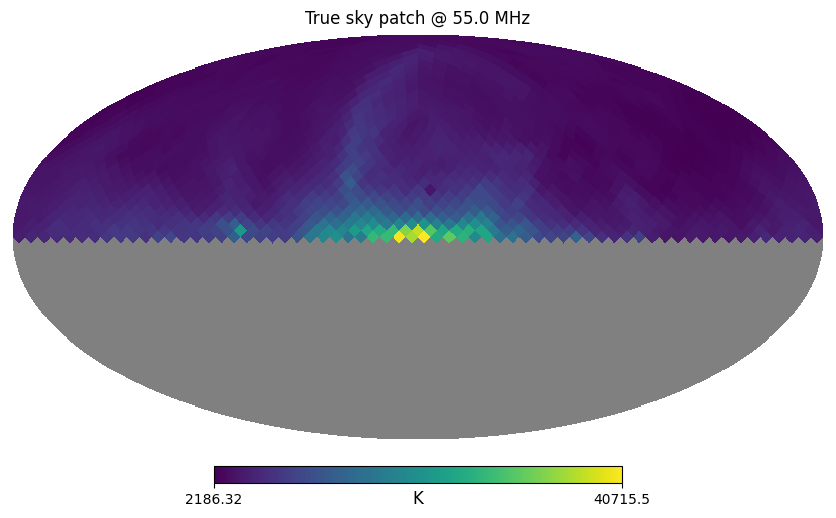

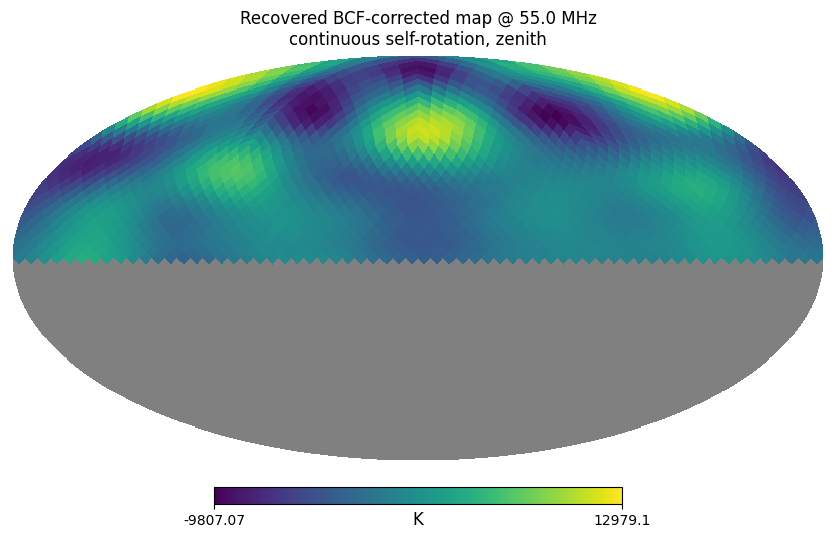

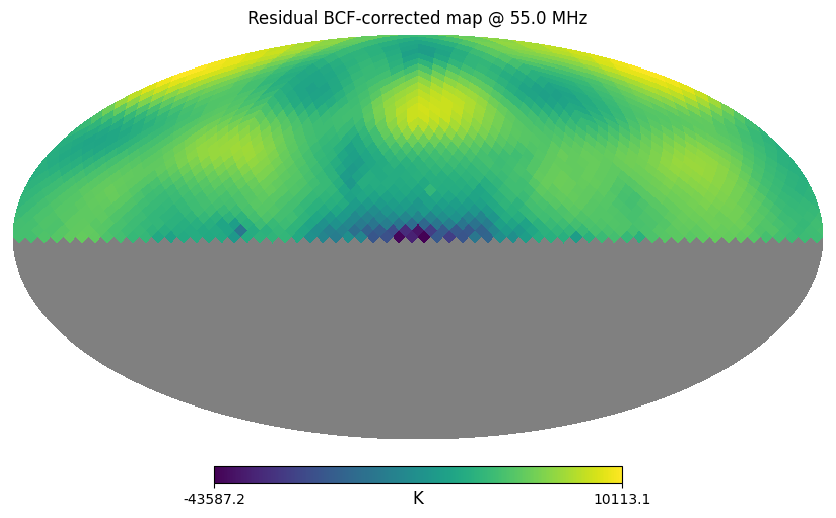

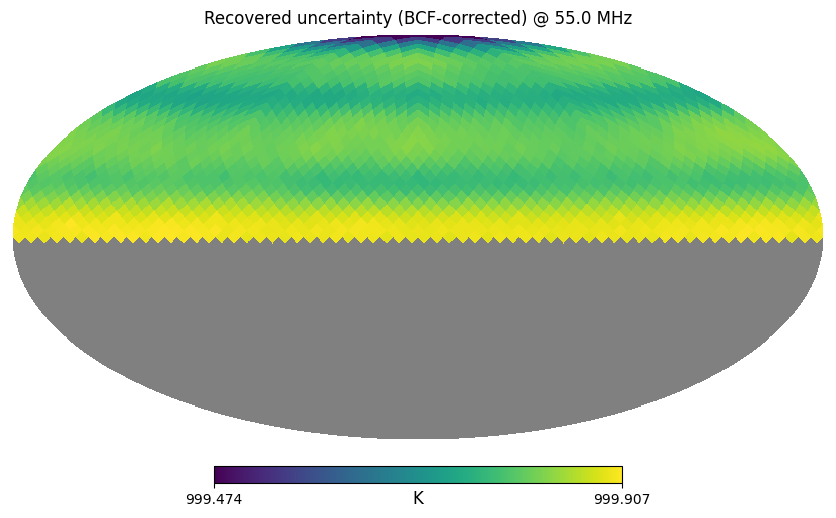

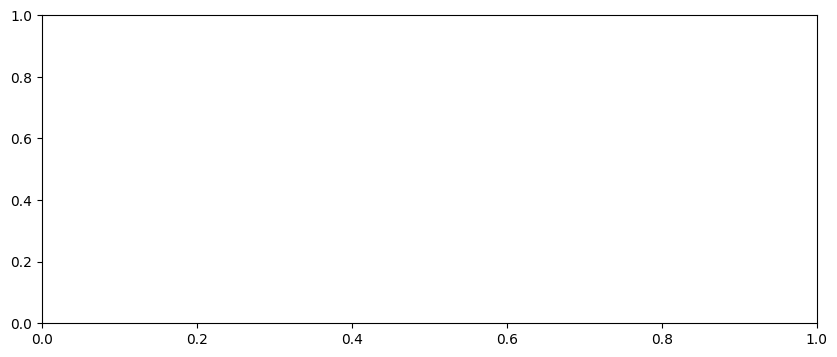

In [9]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from astropy.io import fits
import glob
import re

from limTOD import generate_LSTs_deg, generate_TOD_sky, GDSM_sky_model, HPW_mapmaking

# ============================================================
# CONFIG
# ============================================================

BEAM_GLOB = "../data/HornWet/HornWet*.fits"

ANT_LAT = 53.2421
ANT_LON = -2.3067
ANT_H   = 100.0

START_TIME = "2026-04-01 20:41:56.397"

# DT = 60.0                       # 1 min cadence
# N_HOURS = 24
# N_TIME = int((N_HOURS * 3600) / DT)

# time_list = np.arange(N_TIME) * DT
# time_hours = time_list / 3600.0

DT = 10.0
N_HOURS = 24
N_TIME = int((N_HOURS * 3600) / DT)

time_list = np.arange(N_TIME) * DT

# one full rotation every 60 s
rotation_period_sec = 3600.0
selfrot_deg_list = (time_list / rotation_period_sec * 360.0) % 360.0

BEAM_NSIDE = 128
SKY_NSIDE = 32
MAP_NSIDE = 16                 # target map nside for reconstruction

TARGET_FREQ = 55.0              # target horn-beam channel
REF_FREQ = 70.0                 # BCF reference frequency

# continuous self rotation: 0 -> 360 over whole observation
# selfrot_deg_list = (time_list / time_list[-1]) * 360.0

# zenith pointing
azimuth_deg_list = np.zeros(N_TIME)
elevation_deg_list = np.full(N_TIME, 90.0)

# ============================================================
# LOAD HORN BEAMS
# ============================================================

beam_files = sorted(glob.glob(BEAM_GLOB))
if len(beam_files) == 0:
    raise FileNotFoundError(f"No beam FITS found matching {BEAM_GLOB}")

beam_dict = {}

for f in beam_files:
    m = re.search(r"(\d+\.\d+)", f)
    if m is None:
        continue

    freq = float(m.group(1))

    with fits.open(f) as hdul:
        beam = np.array(hdul[1].data.field(0)).reshape(-1)

    beam = np.nan_to_num(beam)
    beam[beam < 0] = 0.0
    beam /= np.sum(beam)

    beam_dict[freq] = beam

freq_list = np.array(sorted(beam_dict.keys()))
if len(freq_list) == 0:
    raise RuntimeError("No usable horn beams were loaded.")

def get_horn_beam_for_freq(freq, nside=BEAM_NSIDE):
    f_near = freq_list[np.argmin(np.abs(freq_list - freq))]
    beam = beam_dict[f_near].copy()

    native_nside = hp.npix2nside(len(beam))
    if native_nside != nside:
        beam = hp.ud_grade(beam, nside_out=nside, power=-2)

    beam = np.nan_to_num(beam)
    beam[beam < 0] = 0.0

    s = np.sum(beam)
    if s <= 0:
        raise ValueError(f"Beam at {f_near} MHz has zero total weight.")
    beam /= s

    return f_near, beam

beam_freq_used, beam_map = get_horn_beam_for_freq(TARGET_FREQ, nside=BEAM_NSIDE)
ref_freq_used, beam_ref_map = get_horn_beam_for_freq(REF_FREQ, nside=BEAM_NSIDE)

print(f"Using horn beam at target frequency {beam_freq_used:.2f} MHz")
print(f"Using horn beam at reference frequency {ref_freq_used:.2f} MHz")

# ============================================================
# GENERATE SKY + LST
# ============================================================

LST_deg_list = generate_LSTs_deg(
    ANT_LAT,
    ANT_LON,
    ANT_H,
    time_list,
    start_time_utc=START_TIME,
)

sky_map = GDSM_sky_model(freq=beam_freq_used, nside=SKY_NSIDE)
sky_ref_map = GDSM_sky_model(freq=ref_freq_used, nside=SKY_NSIDE)

# ============================================================
# GENERATE RAW TOD FOR TARGET FREQUENCY CHANNEL
# ============================================================

tod = generate_TOD_sky(
    beam_map,
    sky_map,
    LST_deg_list,
    ANT_LAT,
    azimuth_deg_list,
    elevation_deg_list,
    selfrot_deg_list,
    nside_hires=BEAM_NSIDE,
    normalize_beam=True,
)

print("Raw TOD shape:", tod.shape)

# ============================================================
# COMPUTE BCF
# ============================================================
# Using the paper-style normalized-beam form:
# BCF(t) = [integral T_sky(nu_ref) * B(nu)] / [integral T_sky(nu_ref) * B(nu_ref)]
#
# Since your beams are explicitly normalized on load, this is the
# appropriate form for this script.

T_num = generate_TOD_sky(
    beam_map,
    sky_ref_map,
    LST_deg_list,
    ANT_LAT,
    azimuth_deg_list,
    elevation_deg_list,
    selfrot_deg_list,
    nside_hires=BEAM_NSIDE,
    normalize_beam=True,
)

T_ref = generate_TOD_sky(
    beam_ref_map,
    sky_ref_map,
    LST_deg_list,
    ANT_LAT,
    azimuth_deg_list,
    elevation_deg_list,
    selfrot_deg_list,
    nside_hires=BEAM_NSIDE,
    normalize_beam=True,
)

eps = 1e-12
BCF = T_num / np.maximum(T_ref, eps)

print("BCF shape:", BCF.shape)
print(f"BCF min = {BCF.min():.6f}, max = {BCF.max():.6f}")

# ============================================================
# APPLY BCF TO TOD ITSELF
# ============================================================

tod_bcf_corr = tod / np.maximum(BCF, eps)

print("BCF-corrected TOD shape:", tod_bcf_corr.shape)

# ============================================================
# MAP MAKER SETUP
# ============================================================

mapper = HPW_mapmaking(
    beam_map=beam_map,
    LST_deg_list_group=LST_deg_list,
    lat_deg=ANT_LAT,
    azimuth_deg_list_group=azimuth_deg_list,
    elevation_deg_list_group=elevation_deg_list,
    selfrot_deg_list_group=selfrot_deg_list,
    threshold=0.05,
    nside_hires=BEAM_NSIDE,
    nside_target=MAP_NSIDE,
    beam_truncate_frac_thres=0.01,
)

# ============================================================
# RUN MAP MAKING ON BCF-CORRECTED TOD
# ============================================================

sky_estimation, sky_uncertainty = mapper(
    TOD_group=tod_bcf_corr,      # <-- corrected TOD goes into solver
    dtime=DT,
    cutoff_freq_group=0.001,
    gain_group=1.0,
    regularization=1e-6,
    filter_order=4,
)

pixel_indices = mapper.pixel_indices

print("Recovered sky parameter shape:", sky_estimation.shape)
print("Recovered uncertainty shape:", sky_uncertainty.shape)
print("Number of selected pixels:", len(pixel_indices))

# ============================================================
# PUT PATCH BACK INTO FULL HEALPIX MAP
# ============================================================

npix_target = hp.nside2npix(MAP_NSIDE)

recovered_map_full = np.full(npix_target, hp.UNSEEN, dtype=float)
uncertainty_map_full = np.full(npix_target, hp.UNSEEN, dtype=float)

recovered_map_full[pixel_indices] = sky_estimation
uncertainty_map_full[pixel_indices] = sky_uncertainty

# truth map at target nside for comparison
truth_map_target = hp.ud_grade(sky_map, nside_out=MAP_NSIDE)

truth_patch_full = np.full(npix_target, hp.UNSEEN, dtype=float)
truth_patch_full[pixel_indices] = truth_map_target[pixel_indices]

residual_map_full = np.full(npix_target, hp.UNSEEN, dtype=float)
residual_map_full[pixel_indices] = sky_estimation - truth_map_target[pixel_indices]

# ============================================================
# PLOTS
# ============================================================

hp.mollview(
    truth_patch_full,
    title=f"True sky patch @ {beam_freq_used:.1f} MHz",
    unit="K"
)

hp.mollview(
    recovered_map_full,
    title=f"Recovered BCF-corrected map @ {beam_freq_used:.1f} MHz\ncontinuous self-rotation, zenith",
    unit="K"
)

hp.mollview(
    residual_map_full,
    title=f"Residual BCF-corrected map @ {beam_freq_used:.1f} MHz",
    unit="K"
)

hp.mollview(
    uncertainty_map_full,
    title=f"Recovered uncertainty (BCF-corrected) @ {beam_freq_used:.1f} MHz",
    unit="K"
)

plt.figure(figsize=(10, 4))
plt.plot(time_hours, tod, label="Raw TOD")
plt.plot(time_hours, tod_bcf_corr, label="BCF-corrected TOD")
plt.xlabel("Time [hours]")
plt.ylabel("TOD [K]")
plt.title(f"TOD @ {beam_freq_used:.1f} MHz (continuous self-rotation, zenith)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_hours, BCF)
plt.xlabel("Time [hours]")
plt.ylabel("BCF")
plt.title(f"BCF vs time @ {beam_freq_used:.1f} MHz")
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# SIMPLE SUMMARY METRICS ON THE SOLVED PATCH
# ============================================================

valid = pixel_indices
rmse = np.sqrt(np.mean((sky_estimation - truth_map_target[valid])**2))
bias = np.mean(sky_estimation - truth_map_target[valid])

print(f"Patch RMSE (BCF-corrected): {rmse:.3f} K")
print(f"Patch bias (BCF-corrected): {bias:.3f} K")

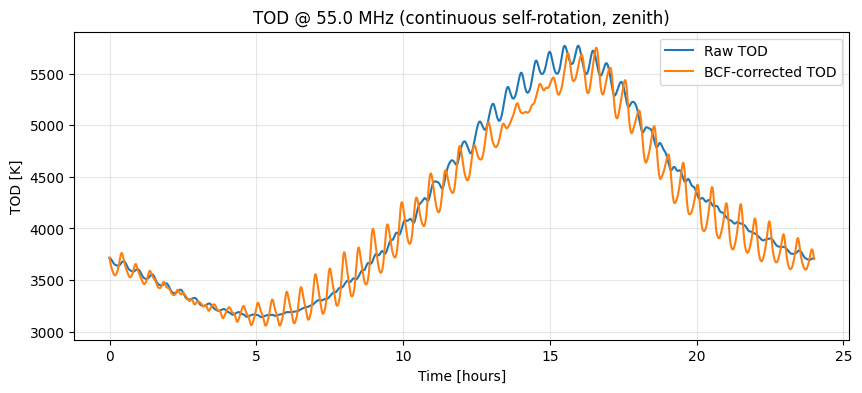

In [10]:
time_hours = time_list / 3600.0

plt.figure(figsize=(10, 4))
plt.plot(time_hours, tod, label="Raw TOD")
plt.plot(time_hours, tod_bcf_corr, label="BCF-corrected TOD")
plt.xlabel("Time [hours]")
plt.ylabel("TOD [K]")
plt.title(f"TOD @ {beam_freq_used:.1f} MHz (continuous self-rotation, zenith)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

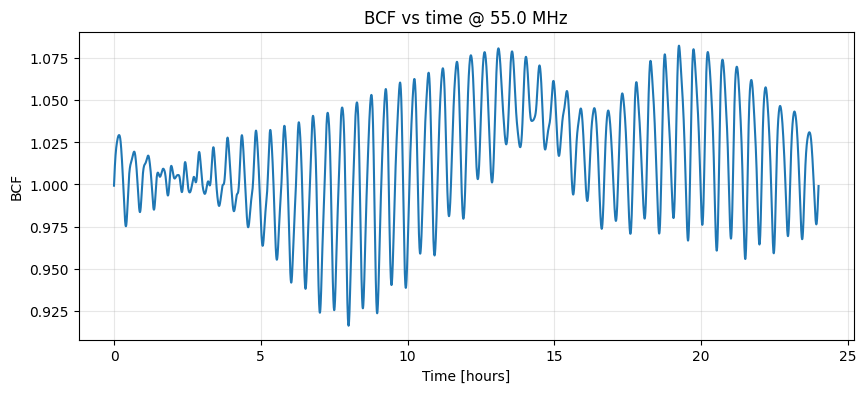

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(time_hours, BCF)
plt.xlabel("Time [hours]")
plt.ylabel("BCF")
plt.title(f"BCF vs time @ {beam_freq_used:.1f} MHz")
plt.grid(alpha=0.3)
plt.show()

### Computed sensible config

Using horn beam at target frequency 55.00 MHz
Using horn beam at reference frequency 70.00 MHz


100%|██████████| 720/720 [00:04<00:00, 176.17it/s]


Raw TOD shape: (720,)


100%|██████████| 720/720 [00:04<00:00, 176.79it/s]


BCF shape: (720,)
BCF min = 0.916348, max = 1.080466
BCF-corrected TOD shape: (720,)

Step 1: Generating the stacked abs(beam) map ... 



100%|██████████| 720/720 [00:03<00:00, 185.86it/s]



Step 2: Selecting pixels above threshold sensitivity ... 

Number of data points: 720
Number of selected pixels: 336


100%|██████████| 720/720 [00:03<00:00, 191.54it/s]


Number of selected pixels: 336
Number of TOD samples: 720
RMS difference between RAW and BCF maps: 14.088 K
Mean difference between RAW and BCF maps: 0.370 K


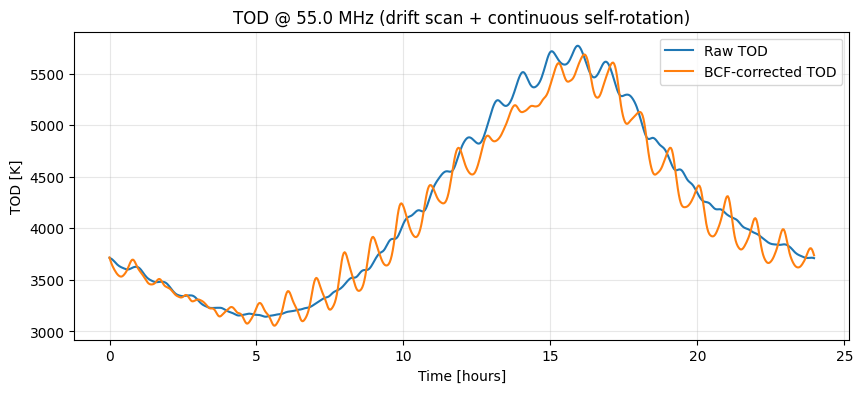

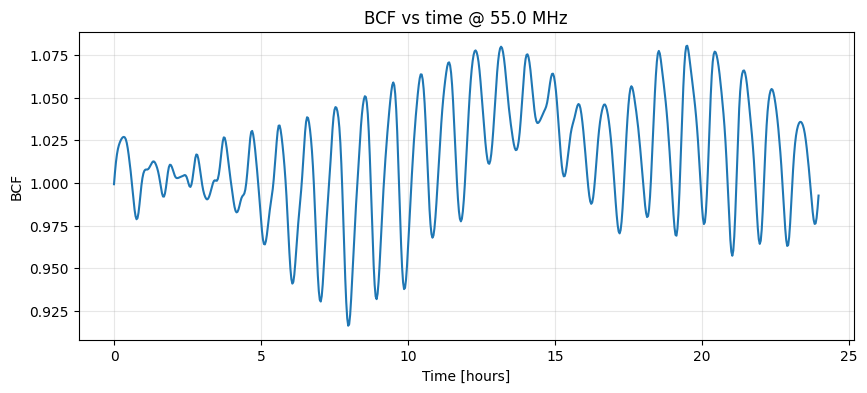

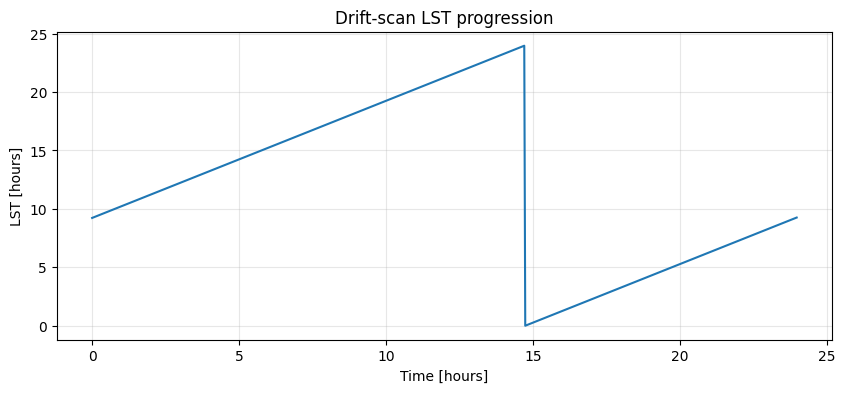

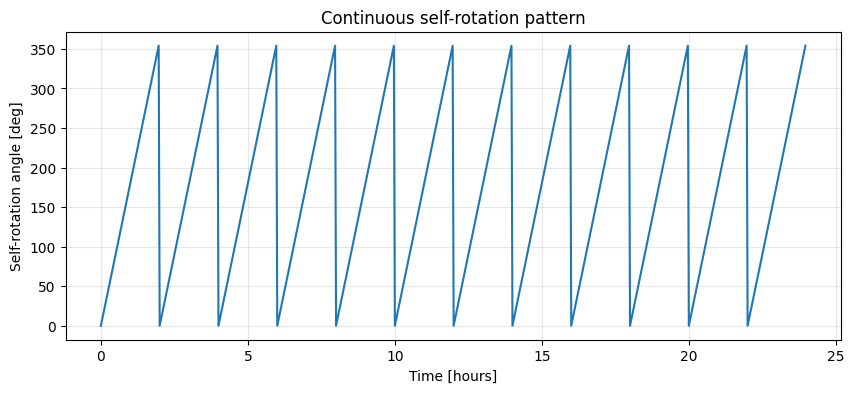

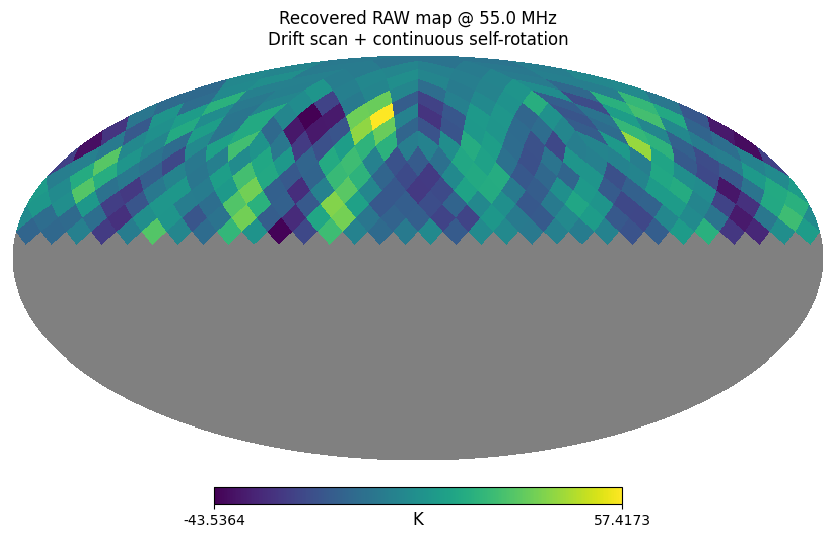

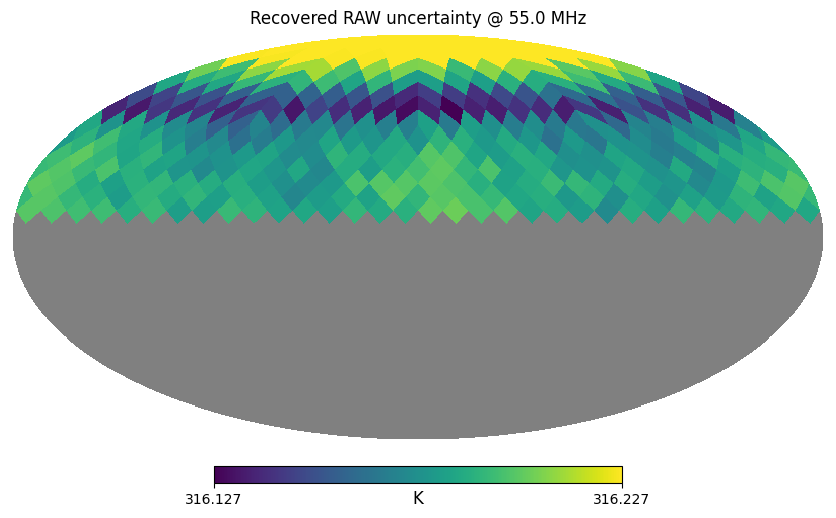

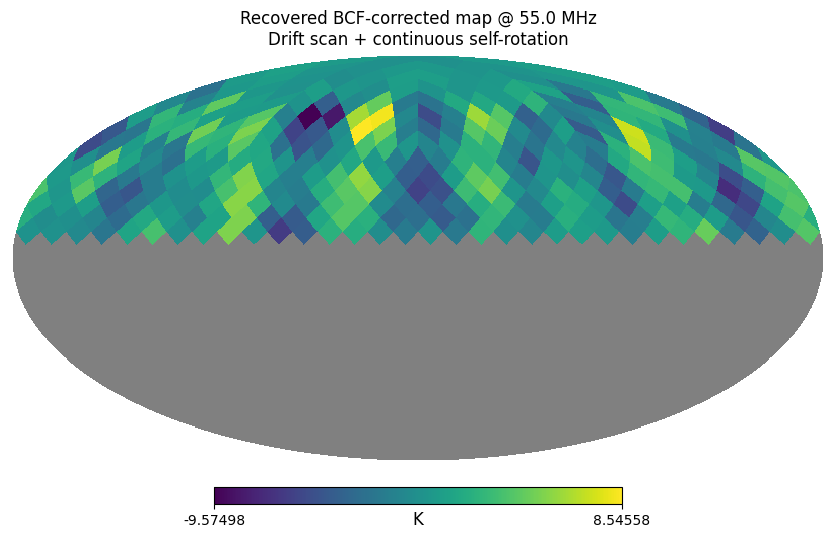

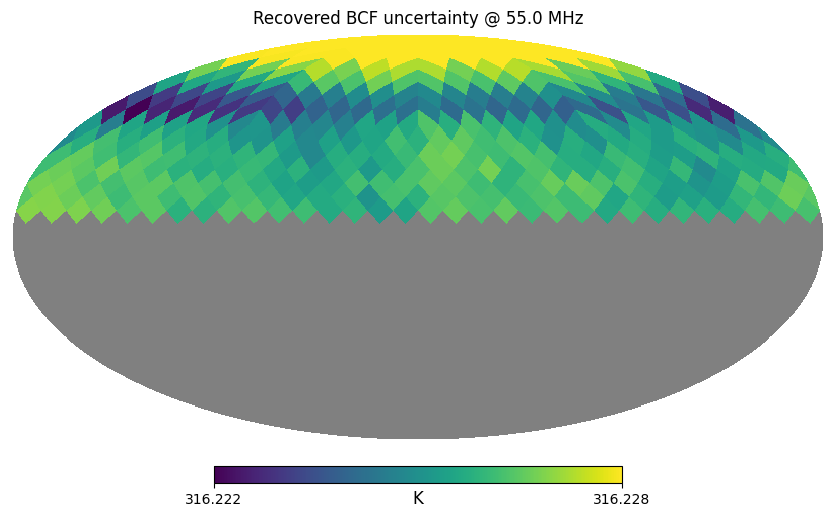

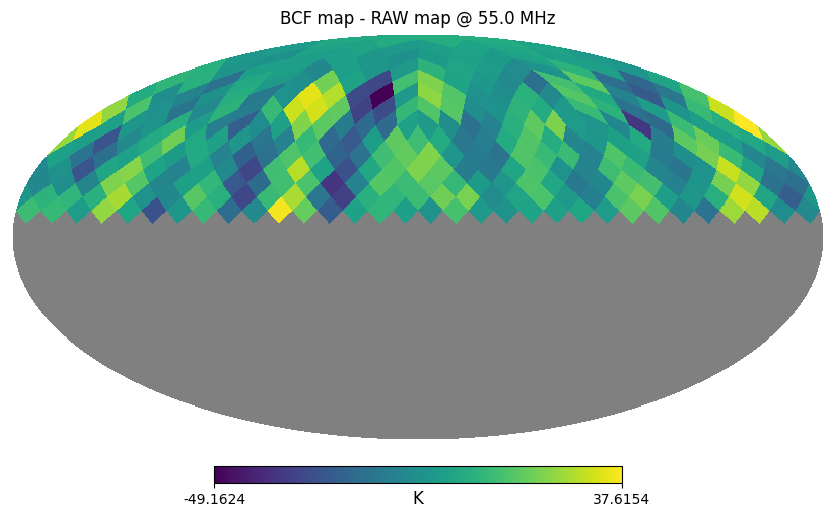

In [12]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from astropy.io import fits
import glob
import re

from limTOD import generate_LSTs_deg, generate_TOD_sky, GDSM_sky_model, HPW_mapmaking

# ============================================================
# CONFIG
# ============================================================

BEAM_GLOB = "../data/HornWet/HornWet*.fits"

ANT_LAT = 53.2421
ANT_LON = -2.3067
ANT_H   = 100.0

START_TIME = "2026-04-01 20:41:56.397"

# sensible sampling / solving balance
DT = 120.0                      # 2 min cadence
N_HOURS = 24
N_TIME = int((N_HOURS * 3600) / DT)

time_list = np.arange(N_TIME) * DT
time_hours = time_list / 3600.0

# one full beam self-rotation every 2 hours
rotation_period_sec = 7200.0
selfrot_deg_list = (time_list / rotation_period_sec * 360.0) % 360.0

# drift scan:
# fixed pointing, sky changes through LST
azimuth_deg_list = np.zeros(N_TIME)
elevation_deg_list = np.full(N_TIME, 90.0)   # straight up / zenith

BEAM_NSIDE = 64
SKY_NSIDE = 32
MAP_NSIDE = 8

TARGET_FREQ = 55.0
REF_FREQ = 70.0

THRESHOLD = 0.10
TRUNC_FRAC = 0.01
REGULARIZATION = 1e-5
CUTOFF_FREQ = 0.001

# ============================================================
# LOAD HORN BEAMS
# ============================================================

beam_files = sorted(glob.glob(BEAM_GLOB))
if len(beam_files) == 0:
    raise FileNotFoundError(f"No beam FITS found matching {BEAM_GLOB}")

beam_dict = {}

for f in beam_files:
    m = re.search(r"(\d+\.\d+)", f)
    if m is None:
        continue

    freq = float(m.group(1))

    with fits.open(f) as hdul:
        beam = np.array(hdul[1].data.field(0)).reshape(-1)

    beam = np.nan_to_num(beam)
    beam[beam < 0] = 0.0
    beam /= np.sum(beam)

    beam_dict[freq] = beam

freq_list = np.array(sorted(beam_dict.keys()))
if len(freq_list) == 0:
    raise RuntimeError("No usable horn beams were loaded.")

def get_horn_beam_for_freq(freq, nside=BEAM_NSIDE):
    f_near = freq_list[np.argmin(np.abs(freq_list - freq))]
    beam = beam_dict[f_near].copy()

    native_nside = hp.npix2nside(len(beam))
    if native_nside != nside:
        beam = hp.ud_grade(beam, nside_out=nside, power=-2)

    beam = np.nan_to_num(beam)
    beam[beam < 0] = 0.0

    s = np.sum(beam)
    if s <= 0:
        raise ValueError(f"Beam at {f_near} MHz has zero total weight.")
    beam /= s

    return f_near, beam

beam_freq_used, beam_map = get_horn_beam_for_freq(TARGET_FREQ, nside=BEAM_NSIDE)
ref_freq_used, beam_ref_map = get_horn_beam_for_freq(REF_FREQ, nside=BEAM_NSIDE)

print(f"Using horn beam at target frequency {beam_freq_used:.2f} MHz")
print(f"Using horn beam at reference frequency {ref_freq_used:.2f} MHz")

# ============================================================
# SKY + LST
# ============================================================

LST_deg_list = generate_LSTs_deg(
    ANT_LAT,
    ANT_LON,
    ANT_H,
    time_list,
    start_time_utc=START_TIME,
)

sky_map = GDSM_sky_model(freq=beam_freq_used, nside=SKY_NSIDE)
sky_ref_map = GDSM_sky_model(freq=ref_freq_used, nside=SKY_NSIDE)

# ============================================================
# RAW TOD
# ============================================================

tod_raw = generate_TOD_sky(
    beam_map,
    sky_map,
    LST_deg_list,
    ANT_LAT,
    azimuth_deg_list,
    elevation_deg_list,
    selfrot_deg_list,
    nside_hires=BEAM_NSIDE,
    normalize_beam=True,
)

print("Raw TOD shape:", tod_raw.shape)

# ============================================================
# COMPUTE BCF
# ============================================================
# Normalized-beam version:
# BCF(t) = [integral T_sky(nu_ref) * B(nu)] /
#          [integral T_sky(nu_ref) * B(nu_ref)]

T_num = generate_TOD_sky(
    beam_map,
    sky_ref_map,
    LST_deg_list,
    ANT_LAT,
    azimuth_deg_list,
    elevation_deg_list,
    selfrot_deg_list,
    nside_hires=BEAM_NSIDE,
    normalize_beam=True,
)

T_ref = generate_TOD_sky(
    beam_ref_map,
    sky_ref_map,
    LST_deg_list,
    ANT_LAT,
    azimuth_deg_list,
    elevation_deg_list,
    selfrot_deg_list,
    nside_hires=BEAM_NSIDE,
    normalize_beam=True,
)

eps = 1e-12
BCF = T_num / np.maximum(T_ref, eps)

tod_bcf = tod_raw / np.maximum(BCF, eps)

print("BCF shape:", BCF.shape)
print(f"BCF min = {BCF.min():.6f}, max = {BCF.max():.6f}")
print("BCF-corrected TOD shape:", tod_bcf.shape)

# ============================================================
# MAP MAKER SETUP
# ============================================================

mapper = HPW_mapmaking(
    beam_map=beam_map,
    LST_deg_list_group=LST_deg_list,
    lat_deg=ANT_LAT,
    azimuth_deg_list_group=azimuth_deg_list,
    elevation_deg_list_group=elevation_deg_list,
    selfrot_deg_list_group=selfrot_deg_list,
    threshold=THRESHOLD,
    nside_hires=BEAM_NSIDE,
    nside_target=MAP_NSIDE,
    beam_truncate_frac_thres=TRUNC_FRAC,
)

pixel_indices = mapper.pixel_indices
print("Number of selected pixels:", len(pixel_indices))
print("Number of TOD samples:", N_TIME)

# ============================================================
# MAP MAKING FUNCTION
# ============================================================

def run_mapmaking(tod_input):
    sky_estimation, sky_uncertainty = mapper(
        TOD_group=tod_input,
        dtime=DT,
        cutoff_freq_group=CUTOFF_FREQ,
        gain_group=1.0,
        regularization=REGULARIZATION,
        filter_order=4,
    )
    return sky_estimation, sky_uncertainty

# raw
sky_est_raw, sky_unc_raw = run_mapmaking(tod_raw)

# BCF corrected
sky_est_bcf, sky_unc_bcf = run_mapmaking(tod_bcf)

# ============================================================
# PUT PATCH BACK INTO FULL MAP
# ============================================================

npix_target = hp.nside2npix(MAP_NSIDE)

def build_full_patch_map(values, pixel_indices, npix_target):
    full = np.full(npix_target, hp.UNSEEN, dtype=float)
    full[pixel_indices] = values
    return full

recovered_raw_full = build_full_patch_map(
    sky_est_raw, pixel_indices, npix_target
)
unc_raw_full = build_full_patch_map(
    sky_unc_raw, pixel_indices, npix_target
)

recovered_bcf_full = build_full_patch_map(
    sky_est_bcf, pixel_indices, npix_target
)
unc_bcf_full = build_full_patch_map(
    sky_unc_bcf, pixel_indices, npix_target
)

difference_full = build_full_patch_map(
    sky_est_bcf - sky_est_raw, pixel_indices, npix_target
)

# ============================================================
# SIMPLE INTERNAL METRICS
# ============================================================

rms_map_diff = np.sqrt(np.mean((sky_est_bcf - sky_est_raw) ** 2))
mean_map_diff = np.mean(sky_est_bcf - sky_est_raw)

print(f"RMS difference between RAW and BCF maps: {rms_map_diff:.3f} K")
print(f"Mean difference between RAW and BCF maps: {mean_map_diff:.3f} K")

# ============================================================
# PLOTS: TOD / BCF
# ============================================================

plt.figure(figsize=(10, 4))
plt.plot(time_hours, tod_raw, label="Raw TOD")
plt.plot(time_hours, tod_bcf, label="BCF-corrected TOD")
plt.xlabel("Time [hours]")
plt.ylabel("TOD [K]")
plt.title(f"TOD @ {beam_freq_used:.1f} MHz (drift scan + continuous self-rotation)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_hours, BCF)
plt.xlabel("Time [hours]")
plt.ylabel("BCF")
plt.title(f"BCF vs time @ {beam_freq_used:.1f} MHz")
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# PLOTS: SCAN / ROTATION DIAGNOSTICS
# ============================================================

plt.figure(figsize=(10, 4))
plt.plot(time_hours, LST_deg_list / 15.0)
plt.xlabel("Time [hours]")
plt.ylabel("LST [hours]")
plt.title("Drift-scan LST progression")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_hours, selfrot_deg_list)
plt.xlabel("Time [hours]")
plt.ylabel("Self-rotation angle [deg]")
plt.title("Continuous self-rotation pattern")
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# PLOTS: MAPS WITHOUT BCF
# ============================================================

hp.mollview(
    recovered_raw_full,
    title=f"Recovered RAW map @ {beam_freq_used:.1f} MHz\nDrift scan + continuous self-rotation",
    unit="K"
)

hp.mollview(
    unc_raw_full,
    title=f"Recovered RAW uncertainty @ {beam_freq_used:.1f} MHz",
    unit="K"
)

# ============================================================
# PLOTS: MAPS WITH BCF
# ============================================================

hp.mollview(
    recovered_bcf_full,
    title=f"Recovered BCF-corrected map @ {beam_freq_used:.1f} MHz\nDrift scan + continuous self-rotation",
    unit="K"
)

hp.mollview(
    unc_bcf_full,
    title=f"Recovered BCF uncertainty @ {beam_freq_used:.1f} MHz",
    unit="K"
)

# ============================================================
# PLOTS: DIFFERENCE BETWEEN MAPS
# ============================================================

hp.mollview(
    difference_full,
    title=f"BCF map - RAW map @ {beam_freq_used:.1f} MHz",
    unit="K"
)

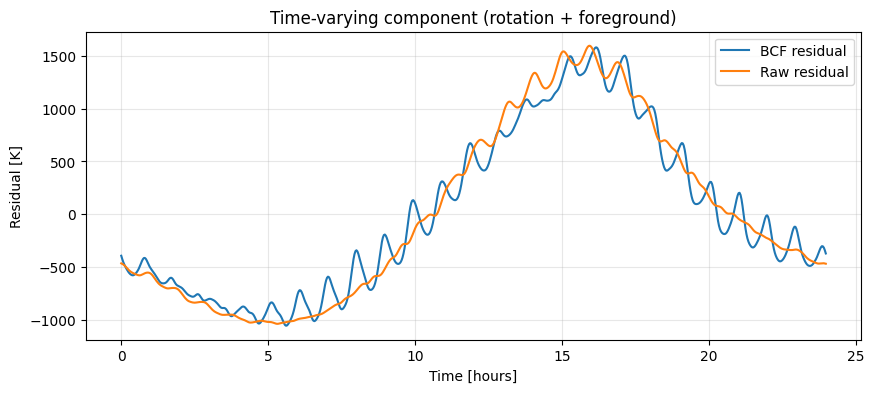

In [15]:
# ============================================================
# MEAN + RESIDUAL ANALYSIS
# ============================================================

mean_raw = np.mean(tod_raw)
mean_bcf = np.mean(tod_bcf)

residual_raw = tod_raw - mean_raw
residual_bcf = tod_bcf - mean_bcf

# plot
plt.figure(figsize=(10,4))
plt.plot(time_hours, residual_bcf, label="BCF residual")
plt.plot(time_hours, residual_raw, label="Raw residual")
plt.xlabel("Time [hours]")
plt.ylabel("Residual [K]")
plt.title("Time-varying component (rotation + foreground)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [16]:
# ============================================================
# SELECT FREQUENCIES
# ============================================================

# Use subset first (important for speed)
freq_subset = freq_list[::3]

print(f"Running {len(freq_subset)} frequency channels")

# ============================================================
# STORAGE
# ============================================================

tod_raw_all = []
tod_bcf_all = []
bcf_all = []
mean_raw = []
mean_bcf = []

# ============================================================
# LOOP OVER FREQUENCY
# ============================================================

for nu in freq_subset:

    print(f"Processing {nu:.2f} MHz")

    # ---------------------------------------
    # beams
    # ---------------------------------------
    _, beam_map = get_horn_beam_for_freq(nu, nside=BEAM_NSIDE)
    _, beam_ref_map = get_horn_beam_for_freq(REF_FREQ, nside=BEAM_NSIDE)

    # ---------------------------------------
    # sky
    # ---------------------------------------
    sky_map = GDSM_sky_model(freq=nu, nside=SKY_NSIDE)
    sky_ref_map = GDSM_sky_model(freq=REF_FREQ, nside=SKY_NSIDE)

    # ---------------------------------------
    # TOD (raw)
    # ---------------------------------------
    tod_raw = generate_TOD_sky(
        beam_map,
        sky_map,
        LST_deg_list,
        ANT_LAT,
        azimuth_deg_list,
        elevation_deg_list,
        selfrot_deg_list,
        nside_hires=BEAM_NSIDE,
        normalize_beam=True,
    )

    # ---------------------------------------
    # BCF
    # ---------------------------------------
    T_num = generate_TOD_sky(
        beam_map,
        sky_ref_map,
        LST_deg_list,
        ANT_LAT,
        azimuth_deg_list,
        elevation_deg_list,
        selfrot_deg_list,
        nside_hires=BEAM_NSIDE,
        normalize_beam=True,
    )

    T_ref = generate_TOD_sky(
        beam_ref_map,
        sky_ref_map,
        LST_deg_list,
        ANT_LAT,
        azimuth_deg_list,
        elevation_deg_list,
        selfrot_deg_list,
        nside_hires=BEAM_NSIDE,
        normalize_beam=True,
    )

    BCF = T_num / np.maximum(T_ref, 1e-12)
    tod_bcf = tod_raw / np.maximum(BCF, 1e-12)

    # ---------------------------------------
    # store
    # ---------------------------------------
    tod_raw_all.append(tod_raw)
    tod_bcf_all.append(tod_bcf)
    bcf_all.append(BCF)

    mean_raw.append(np.mean(tod_raw))
    mean_bcf.append(np.mean(tod_bcf))

# convert to arrays
tod_raw_all = np.array(tod_raw_all)
tod_bcf_all = np.array(tod_bcf_all)
bcf_all = np.array(bcf_all)

mean_raw = np.array(mean_raw)
mean_bcf = np.array(mean_bcf)

Running 21 frequency channels
Processing 55.00 MHz


100%|██████████| 720/720 [00:04<00:00, 167.53it/s]


Processing 56.50 MHz


100%|██████████| 720/720 [00:04<00:00, 167.96it/s]


Processing 58.00 MHz


...

100%|██████████| 720/720 [00:03<00:00, 182.99it/s]


Processing 83.50 MHz


100%|██████████| 720/720 [00:04<00:00, 179.73it/s]


Processing 85.00 MHz


100%|██████████| 720/720 [00:03<00:00, 180.85it/s]


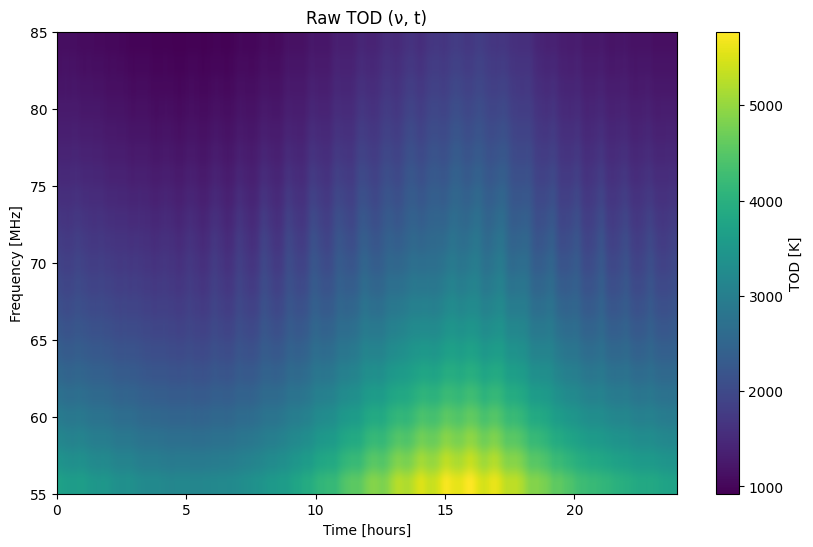

In [17]:
plt.figure(figsize=(10,6))

plt.imshow(
    tod_raw_all,
    aspect="auto",
    origin="lower",
    extent=[time_hours[0], time_hours[-1],
            freq_subset[0], freq_subset[-1]]
)

plt.colorbar(label="TOD [K]")
plt.xlabel("Time [hours]")
plt.ylabel("Frequency [MHz]")
plt.title("Raw TOD (ν, t)")
plt.show()

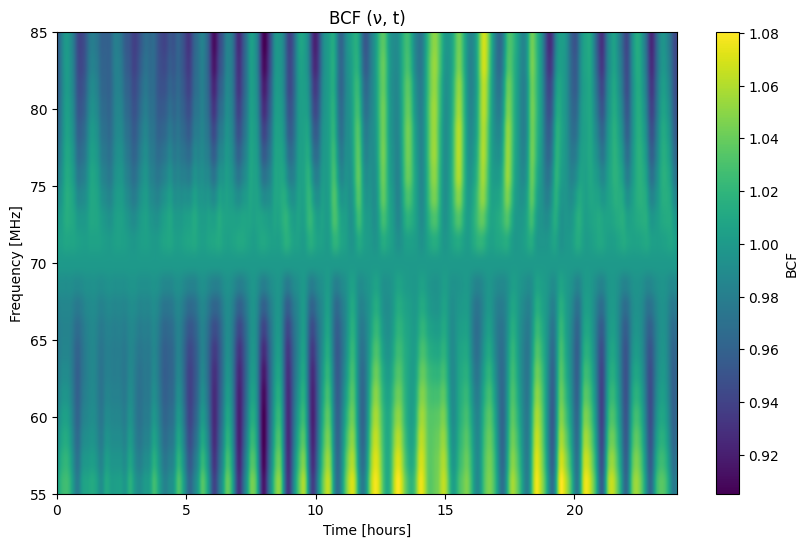

In [18]:
plt.figure(figsize=(10,6))

plt.imshow(
    bcf_all,
    aspect="auto",
    origin="lower",
    extent=[time_hours[0], time_hours[-1],
            freq_subset[0], freq_subset[-1]]
)

plt.colorbar(label="BCF")
plt.xlabel("Time [hours]")
plt.ylabel("Frequency [MHz]")
plt.title("BCF (ν, t)")
plt.show()

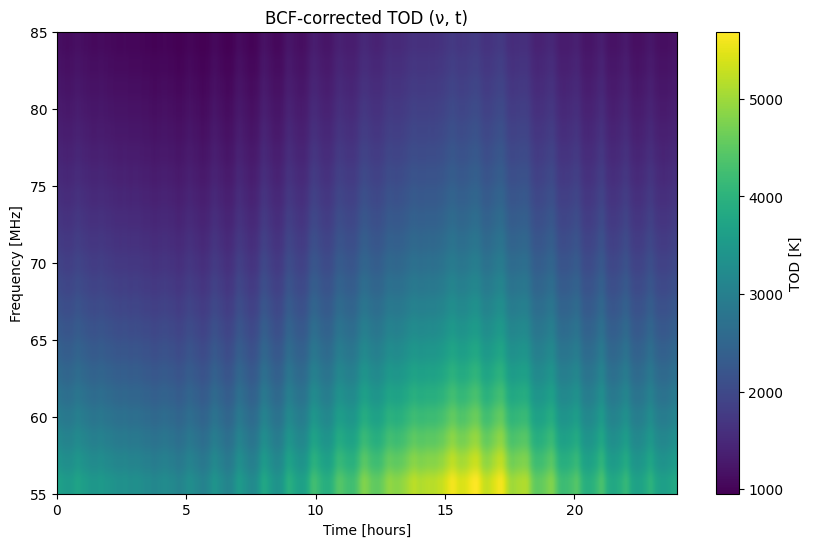

In [19]:
plt.figure(figsize=(10,6))

plt.imshow(
    tod_bcf_all,
    aspect="auto",
    origin="lower",
    extent=[time_hours[0], time_hours[-1],
            freq_subset[0], freq_subset[-1]]
)

plt.colorbar(label="TOD [K]")
plt.xlabel("Time [hours]")
plt.ylabel("Frequency [MHz]")
plt.title("BCF-corrected TOD (ν, t)")
plt.show()

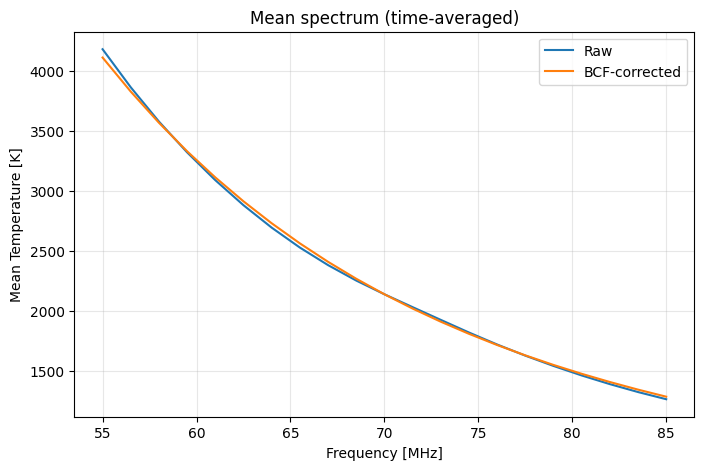

In [20]:
plt.figure(figsize=(8,5))

plt.plot(freq_subset, mean_raw, label="Raw")
plt.plot(freq_subset, mean_bcf, label="BCF-corrected")

plt.xlabel("Frequency [MHz]")
plt.ylabel("Mean Temperature [K]")
plt.title("Mean spectrum (time-averaged)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

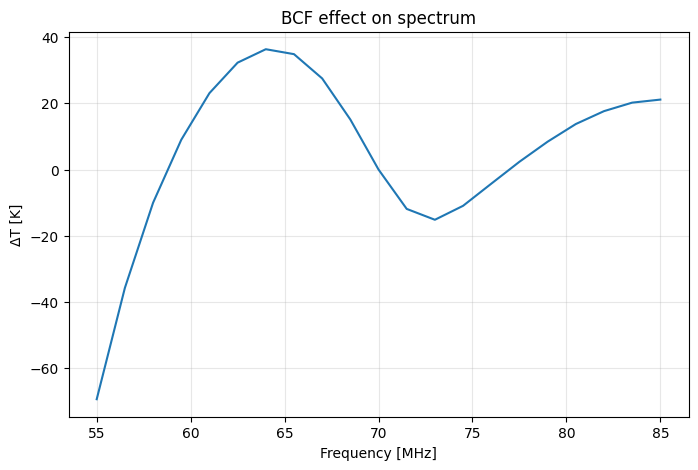

In [21]:
plt.figure(figsize=(8,5))

plt.plot(freq_subset, mean_bcf - mean_raw)

plt.xlabel("Frequency [MHz]")
plt.ylabel("ΔT [K]")
plt.title("BCF effect on spectrum")
plt.grid(alpha=0.3)
plt.show()

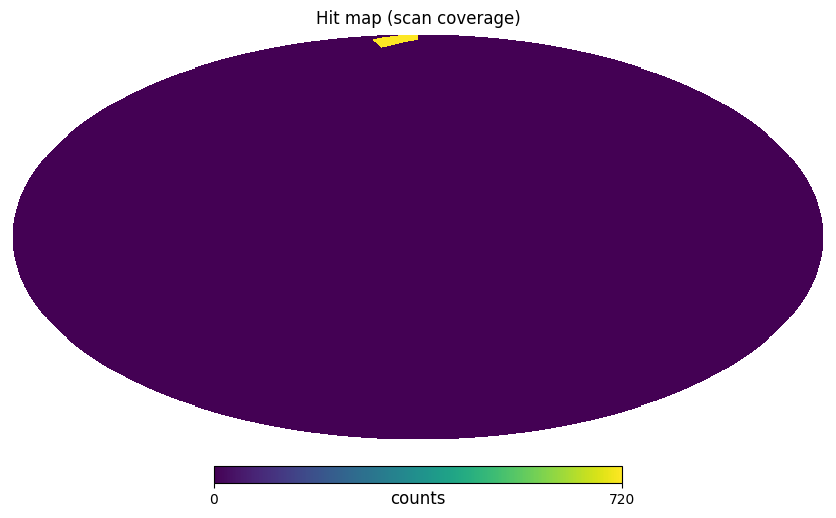

In [22]:
# ============================================================
# BUILD HIT MAP (WHERE YOU LOOKED)
# ============================================================

import healpy as hp

nside = MAP_NSIDE
npix = hp.nside2npix(nside)

hit_map = np.zeros(npix)

for i in range(len(time_list)):

    # pointing direction
    theta = np.radians(90 - elevation_deg_list[i])
    phi = np.radians(azimuth_deg_list[i])

    pix = hp.ang2pix(nside, theta, phi)

    hit_map[pix] += 1

hp.mollview(hit_map, title="Hit map (scan coverage)", unit="counts")

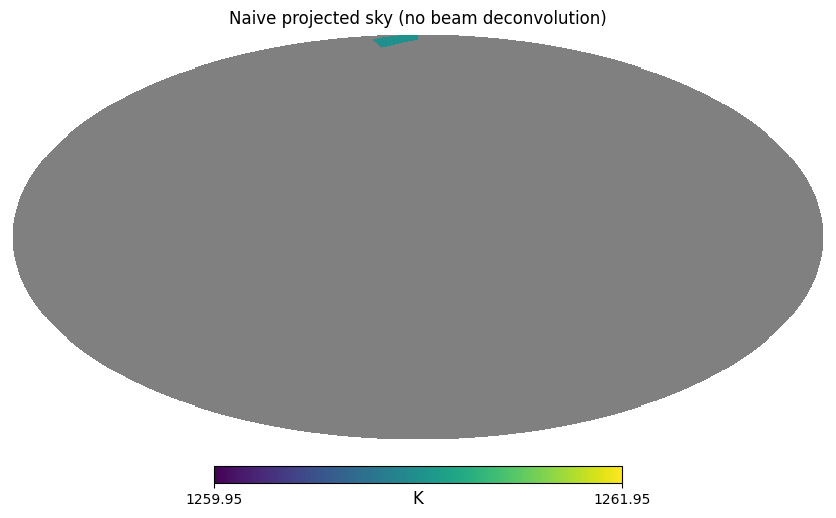

In [23]:
# ============================================================
# PROJECT TOD ONTO SKY (VERY SIMPLE BINNING)
# ============================================================

sky_proj = np.zeros(npix)
counts = np.zeros(npix)

for i in range(len(time_list)):

    theta = np.radians(90 - elevation_deg_list[i])
    phi = np.radians(azimuth_deg_list[i])

    pix = hp.ang2pix(nside, theta, phi)

    sky_proj[pix] += tod_raw[i]
    counts[pix] += 1

# avoid division by zero
mask = counts > 0
sky_proj[mask] /= counts[mask]

sky_proj[~mask] = hp.UNSEEN

hp.mollview(sky_proj, title="Naive projected sky (no beam deconvolution)", unit="K")